## Major Project: Seasonal Agriculture Performance Analysis

#### 1. Introduction to Dataset
The dataset represents agricultural activities carried out across different seasons, geographical areas and farming conditions. It contains information related to farming practices, environmental conditions, crop production, resource usage and economic performance.

The dataset provides students with an opportunity to explore how agricultural performance changes across seasons and to identify meaningful patterns and differences through data analysis.

#### 2. Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

The objective is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

#### 3. Objective
The primary objective of this project is to analyze agricultural data from different seasons and identify meaningful patterns, trends, relationships and differences in agricultural performance.

-> Explore and understand the dataset.  
-> Clean and prepare the data for analysis.  
-> Examine how agricultural performance varies across seasons.  
-> Identify important seasonal patterns and trends.  
-> Investigate relationships between seasonal conditions and agricultural outcomes.  
-> Compare relevant groups within different seasons.  
-> Identify significant differences or unusual patterns.  
-> Apply appropriate statistical and visualization techniques.  
-> Interpret findings based on evidence from the dataset.  
-> Develop meaningful conclusions and data-driven recommendations.

#### Importing Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load the dataset

In [19]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


### Step - 1. Understand the dataset

In [20]:
# Check the shape of the dataset
print("Shape of dataset:", df.shape)

Shape of dataset: (4000, 28)


In [21]:
print("Rows:",df.shape[0],"and Columns:",df.shape[1])

Rows: 4000 and Columns: 28


In [22]:
# Basic Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

#### 1. Text columns — 6
Farm_ID   State   District   Crop   Season   Irrigation_Method

#### 2. Numerical columns — 22
Farm_Area_Hectares   Rainfall_mm   Avg_Temperature_C   Yield_Tonnes_Ha   Production_Tonnes   Revenue_INR   Profit_INR   Water_Used_m3

#### 3. We have some missing values
Rainfall = 3952 non-null So: 4000 - 3952 = 48 missing

Soil Moisture = 3960 non-null So: 4000 - 3960 = 40 missing

Yield = 3968 non-null So: 4000 - 3968 = 32 missing

48 + 40 + 32 = 120 missing values

In [23]:
# check Duplicate rows
df.duplicated().sum()

np.int64(0)

#### Understand categorical columns

In [24]:
df['Season'].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

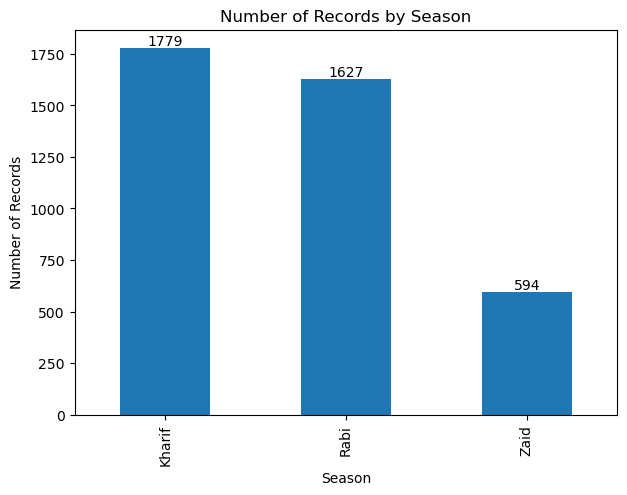

In [25]:
season_counts = df['Season'].value_counts()

plt.figure(figsize=(7,5))
season_counts.plot(kind='bar')

plt.title('Number of Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')

for i, value in enumerate(season_counts.values):
    plt.text(i, value + 0.05, str(value), ha='center', va='bottom')

plt.show()

In [26]:
df['Crop'].value_counts()

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

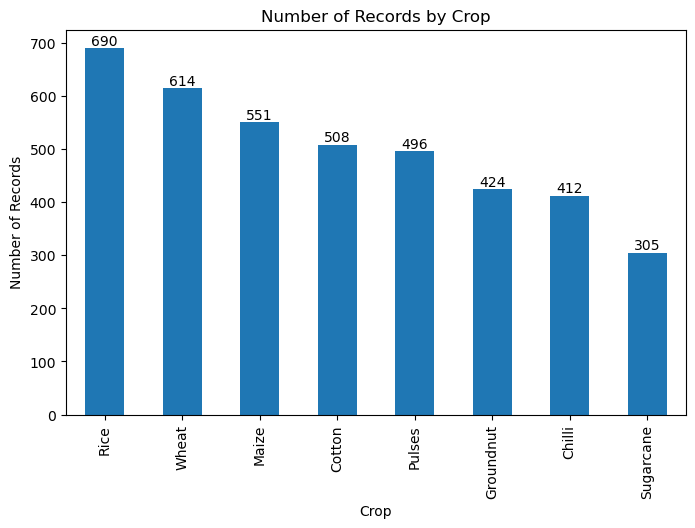

In [27]:
# Bar chart: Number of Records by Crop
crop_counts = df['Crop'].value_counts()

plt.figure(figsize=(8, 5))
bars = crop_counts.plot(kind='bar')

plt.title('Number of Records by Crop')
plt.xlabel('Crop')
plt.ylabel('Number of Records')

for i, value in enumerate(crop_counts.values):
    plt.text(i, value + 0.05, str(value), ha='center', va='bottom')

plt.show()

In [28]:
df['Irrigation_Method'].value_counts()

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64

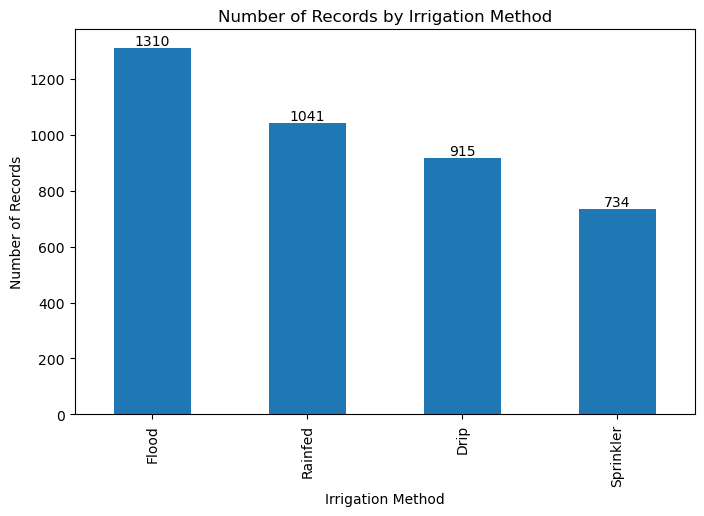

In [29]:
irrigation_counts = df['Irrigation_Method'].value_counts()

plt.figure(figsize=(8,5))
irrigation_counts.plot(kind='bar')

plt.title('Number of Records by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Number of Records')

for i, value in enumerate(irrigation_counts.values):
    plt.text(i, value + 0.05, str(value), ha='center', va='bottom')

plt.show()

In [30]:
df['State'].value_counts()

State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

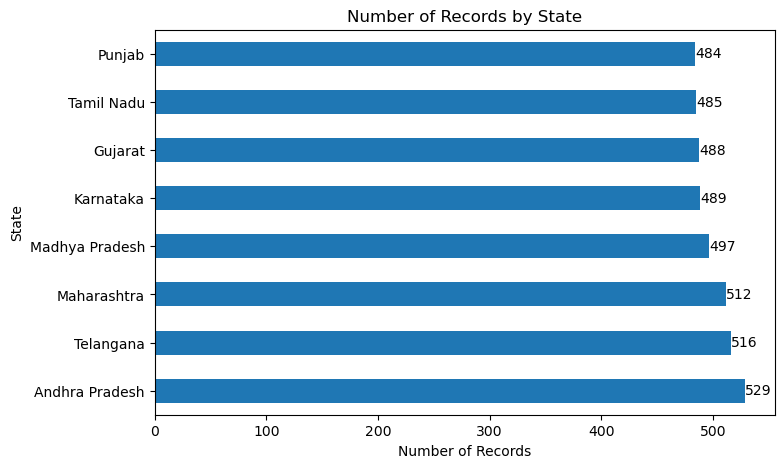

In [31]:
state_counts = df['State'].value_counts()

plt.figure(figsize=(8,5))
state_counts.plot(kind='barh')

plt.title('Number of Records by State')
plt.xlabel('Number of Records')
plt.ylabel('State')

for i, value in enumerate(state_counts.values):
    plt.text(value + 0.05, i, str(value), va='center')

plt.show()

In [32]:
df['District'].value_counts()

District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

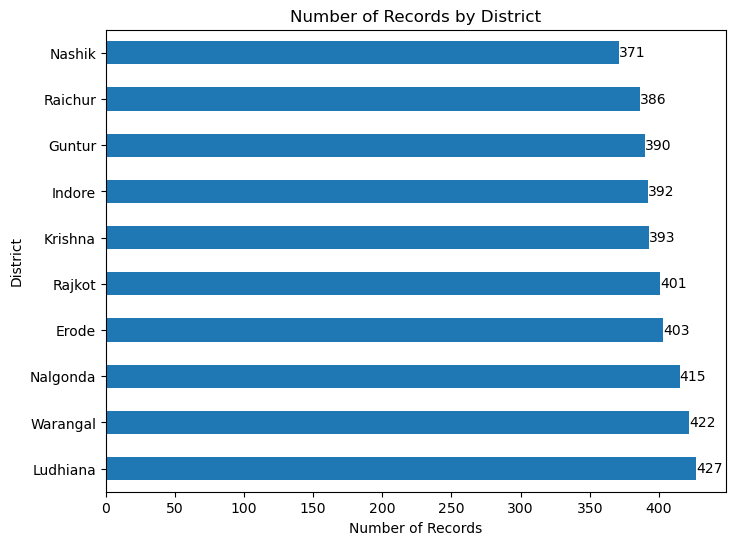

In [33]:
district_counts = df['District'].value_counts()

plt.figure(figsize=(8,6))
district_counts.plot(kind='barh')

plt.title('Number of Records by District')
plt.xlabel('Number of Records')
plt.ylabel('District')


for i, value in enumerate(district_counts.values):
    plt.text(value + 0.05, i, str(value), va='center')

plt.show()

#### Descriptive Statistics

In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [35]:
df[['Humidity_pct',
    'Soil_Moisture_pct',
    'Seed_Quality_Score',
    'Disease_Pest_Risk_pct']].describe()

,Humidity_pct,Soil_Moisture_pct,Seed_Quality_Score,Disease_Pest_Risk_pct
count,4000.000000,3960.000000,4000.000000,4000.000000
mean,63.210500,26.508232,0.826138,46.365875
std,11.960834,6.712484,0.101747,12.424417
min,25.000000,8.000000,0.650000,5.000000
25%,54.775000,21.700000,0.740000,37.300000
50%,63.000000,26.400000,0.830000,46.400000
75%,71.900000,31.300000,0.910000,54.900000
max,95.000000,47.000000,1.000000,88.900000


In [36]:
df[['Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3']].describe()

,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3
count,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000
mean,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250
std,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306
min,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000
25%,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000
50%,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000
75%,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000
max,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000


### Step - 2. Data Cleaning

#### Check missing values

In [37]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [38]:
# Check rainfall by season

df.groupby('Season')['Rainfall_mm'].median()

Season
Kharif    854.75
Rabi      430.30
Zaid      283.30
Name: Rainfall_mm, dtype: float64

In [39]:
df['Rainfall_mm'] = df.groupby('Season')['Rainfall_mm'].transform(
    lambda x: x.fillna(x.median()))

In [40]:
df['Rainfall_mm'].isnull().sum()

np.int64(0)

In [41]:
df.groupby('Season')['Soil_Moisture_pct'].median()

Season
Kharif    31.2
Rabi      24.0
Zaid      19.1
Name: Soil_Moisture_pct, dtype: float64

In [42]:
df['Soil_Moisture_pct'] = df.groupby('Season')['Soil_Moisture_pct'].transform(
    lambda x: x.fillna(x.median()))

In [43]:
df['Soil_Moisture_pct'].isnull().sum()

np.int64(0)

In [44]:
df.groupby('Season')['Yield_Tonnes_Ha'].median()

Season
Kharif    1.95
Rabi      1.66
Zaid      1.45
Name: Yield_Tonnes_Ha, dtype: float64

In [45]:
df['Yield_Tonnes_Ha'] = df.groupby('Season')['Yield_Tonnes_Ha'].transform(
    lambda x: x.fillna(x.median()))

In [46]:
df['Yield_Tonnes_Ha'].isnull().sum()

np.int64(0)

In [47]:
df.isnull().sum()

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64

#### Check for Unusual / Incorrect Values

In [48]:
df['Yield_Tonnes_Ha'].describe()

count    4000.000000
mean        5.241955
std        13.311661
min         0.300000
25%         1.050000
50%         1.730000
75%         2.830000
max       101.440000
Name: Yield_Tonnes_Ha, dtype: float64

In [49]:
# Which crops have these high values?

df[df['Yield_Tonnes_Ha'] > 20][['Crop', 
                                'Season', 
                                'Yield_Tonnes_Ha']].sort_values('Yield_Tonnes_Ha', ascending=False)

,Crop,Season,Yield_Tonnes_Ha
1715,Sugarcane,Kharif,101.44
3423,Sugarcane,Kharif,95.79
3525,Sugarcane,Rabi,93.13
1464,Sugarcane,Kharif,91.98
3523,Sugarcane,Kharif,91.46
...,...,...,...
860,Sugarcane,Rabi,22.34
2815,Sugarcane,Rabi,21.89
2351,Sugarcane,Rabi,21.08
3142,Sugarcane,Rabi,20.73


In [50]:
# maximum Yield for each crop
df.groupby('Crop')['Yield_Tonnes_Ha'].max().sort_values(ascending=False)

Crop
Sugarcane    101.44
Maize          6.08
Rice           5.70
Wheat          4.56
Chilli         3.90
Groundnut      3.02
Cotton         2.90
Pulses         2.09
Name: Yield_Tonnes_Ha, dtype: float64

In [51]:
df['Production_Tonnes'].describe()

count    4000.000000
mean       43.246210
std       126.880521
min         0.150000
25%         5.020000
50%        11.770000
75%        24.355000
max      1424.400000
Name: Production_Tonnes, dtype: float64

In [52]:
df[df['Production_Tonnes'] > 500][['Crop', 
                                   'Farm_Area_Hectares', 
                                   'Yield_Tonnes_Ha', 
                                   'Production_Tonnes']].sort_values('Production_Tonnes', ascending=False)

,Crop,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes
3423,Sugarcane,14.87,95.79,1424.40
357,Sugarcane,14.74,84.75,1249.21
3425,Sugarcane,13.96,82.68,1154.21
1930,Sugarcane,14.16,79.25,1122.18
3027,Sugarcane,14.97,73.44,1099.40
...,...,...,...,...
1712,Sugarcane,14.66,34.78,509.87
2822,Sugarcane,13.70,36.91,505.67
2466,Sugarcane,14.36,35.03,503.03
2505,Sugarcane,13.63,36.88,502.67


In [53]:
df['Revenue_INR'].describe()

count    4.000000e+03
mean     6.378600e+05
std      6.369747e+05
min      6.107000e+03
25%      2.075172e+05
50%      4.568305e+05
75%      8.368748e+05
max      5.080900e+06
Name: Revenue_INR, dtype: float64

In [54]:
df[df['Revenue_INR'] > 3000000][['Crop', 
                                 'Farm_Area_Hectares', 
                                 'Yield_Tonnes_Ha',
                                 'Production_Tonnes',
                                 'Market_Price_INR_Tonne', 
                                 'Revenue_INR']].sort_values('Revenue_INR', ascending=False)

,Crop,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Revenue_INR
626,Chilli,14.45,2.92,42.19,120429,5080900
2236,Chilli,12.74,3.90,49.69,101780,5057448
247,Chilli,14.86,3.09,45.92,105082,4825365
1690,Chilli,13.04,3.01,39.25,115222,4522464
3425,Sugarcane,13.96,82.68,1154.21,3886,4485260
3423,Sugarcane,14.87,95.79,1424.40,3109,4428460
357,Sugarcane,14.74,84.75,1249.21,3483,4350998
1930,Sugarcane,14.16,79.25,1122.18,3661,4108301
3683,Chilli,13.48,2.61,35.18,115429,4060792
3983,Chilli,13.68,3.02,41.31,98175,4055609


In [55]:
df['Profit_INR'].describe()

count    4.000000e+03
mean     1.115565e+05
std      5.450819e+05
min     -1.019223e+06
25%     -1.487318e+05
50%      3.673000e+03
75%      2.161878e+05
max      4.345421e+06
Name: Profit_INR, dtype: float64

In [56]:
df[(df['Profit_INR'] > 3000000) | (df['Profit_INR'] < -800000)][['Crop',
                                                                 'Farm_Area_Hectares',
                                                                 'Production_Tonnes',
                                                                 'Revenue_INR',
                                                                 'Total_Cost_INR','Profit_INR']].sort_values('Profit_INR')

,Crop,Farm_Area_Hectares,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
780,Groundnut,14.64,4.39,280139,1299362,-1019223
2210,Wheat,14.27,4.28,102497,1097692,-995195
3625,Maize,13.47,13.07,226503,1207553,-981050
2182,Rice,14.72,14.87,320865,1297725,-976860
104,Wheat,12.30,3.69,98792,1063989,-965197
3394,Wheat,13.41,4.02,99644,1063040,-963396
2730,Rice,11.99,3.60,89197,995279,-906082
1311,Rice,13.55,6.10,163084,1065824,-902740
585,Cotton,13.96,4.19,198300,1094030,-895730
3090,Maize,14.39,5.90,109026,999667,-890641


In [57]:
df['Water_Used_m3'].describe()

count     4000.000000
mean      6045.570250
std       5572.944306
min        128.000000
25%       2268.750000
50%       4435.000000
75%       7829.750000
max      40902.000000
Name: Water_Used_m3, dtype: float64

In [58]:
df[df['Water_Used_m3'] > 20000][['Crop',
                                 'Farm_Area_Hectares', 
                                 'Yield_Tonnes_Ha',
                                 'Production_Tonnes',
                                 'Water_Used_m3']].sort_values('Water_Used_m3', ascending=False)

,Crop,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Water_Used_m3
2920,Sugarcane,14.78,52.62,777.72,40902
762,Sugarcane,14.47,70.62,1021.87,36156
1400,Sugarcane,13.60,50.01,680.14,34392
3780,Sugarcane,13.08,56.17,734.70,33109
1207,Sugarcane,13.85,7.15,99.03,31992
...,...,...,...,...,...
1421,Rice,11.92,4.05,48.28,20359
2280,Sugarcane,8.18,62.43,510.68,20305
52,Rice,11.52,1.69,19.47,20211
1211,Sugarcane,14.85,64.45,957.08,20165


In [59]:
df['Water_Efficiency_t_per_1000m3'].describe()

count    4000.000000
mean        5.385214
std         8.838101
min         0.135000
25%         1.661000
50%         2.937500
75%         5.150250
max        79.800000
Name: Water_Efficiency_t_per_1000m3, dtype: float64

In [60]:
df[df['Water_Efficiency_t_per_1000m3'] > 20][['Crop',
                                              'Farm_Area_Hectares', 
                                              'Yield_Tonnes_Ha',
                                              'Production_Tonnes', 
                                              'Water_Used_m3',
                                              'Water_Efficiency_t_per_1000m3']].sort_values('Water_Efficiency_t_per_1000m3', ascending=False)

,Crop,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Water_Used_m3,Water_Efficiency_t_per_1000m3
3368,Sugarcane,7.37,61.09,450.23,5642,79.800
1347,Sugarcane,10.89,76.14,829.16,10595,78.260
1746,Sugarcane,4.75,59.05,280.49,3601,77.892
2532,Sugarcane,6.09,72.92,444.08,5817,76.342
3482,Sugarcane,9.64,77.32,745.36,9874,75.487
...,...,...,...,...,...,...
3041,Sugarcane,12.04,40.79,491.11,23888,20.559
3966,Sugarcane,7.97,51.04,406.79,19853,20.490
3118,Sugarcane,14.86,41.63,618.62,30397,20.351
154,Sugarcane,9.12,47.88,436.67,21550,20.263


In [61]:
df['Disease_Pest_Risk_pct'].describe()

count    4000.000000
mean       46.365875
std        12.424417
min         5.000000
25%        37.300000
50%        46.400000
75%        54.900000
max        88.900000
Name: Disease_Pest_Risk_pct, dtype: float64

In [62]:
df[['Farm_Area_Hectares',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_pH',
    'Seed_Quality_Score',
    'Disease_Pest_Risk_pct']].describe()

,Farm_Area_Hectares,Avg_Temperature_C,Humidity_pct,Soil_pH,Seed_Quality_Score,Disease_Pest_Risk_pct
count,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000
mean,7.888265,26.81890,63.210500,6.701010,0.826138,46.365875
std,4.223764,3.81818,11.960834,0.641461,0.101747,12.424417
min,0.500000,16.20000,25.000000,5.200000,0.650000,5.000000
25%,4.260000,23.90000,54.775000,6.260000,0.740000,37.300000
50%,7.895000,26.90000,63.000000,6.690000,0.830000,46.400000
75%,11.650000,29.60000,71.900000,7.140000,0.910000,54.900000
max,15.000000,39.70000,95.000000,8.400000,1.000000,88.900000


### Step - 3. Seasonal Analysis

#### Number of records by season

In [63]:
df['Season'].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

#### Average Yield by Season

In [64]:
df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

Season
Kharif    5.629438
Rabi      5.038451
Zaid      4.638872
Name: Yield_Tonnes_Ha, dtype: float64

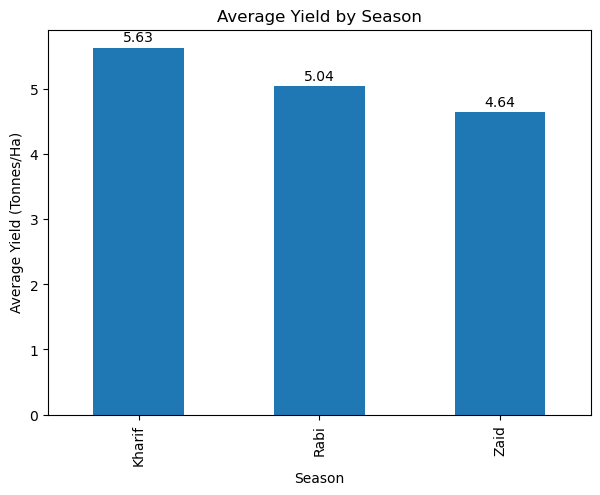

In [65]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
season_yield.plot(kind='bar')

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

for i, value in enumerate(season_yield.values):
    plt.text(i, value + 0.05, f'{value:.2f}', ha='center', va='bottom')
    
plt.show()

#### Average Production by season

In [66]:
df.groupby('Season')['Production_Tonnes'].mean().sort_values(ascending=False)

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64

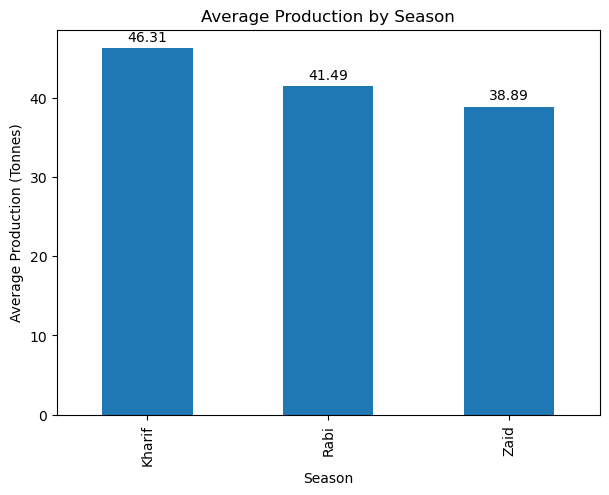

In [67]:
season_production = df.groupby('Season')['Production_Tonnes'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
season_production.plot(kind='bar')

plt.title('Average Production by Season')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')


for i, value in enumerate(season_production.values):
    plt.text(i, value + 0.5, f'{value:.2f}', ha='center', va='bottom')

plt.show()

#### Average Revenue by Season

In [68]:
df.groupby('Season')['Revenue_INR'].mean().sort_values(ascending=False)

Season
Kharif    710719.055649
Rabi      601526.048556
Zaid      519171.904040
Name: Revenue_INR, dtype: float64

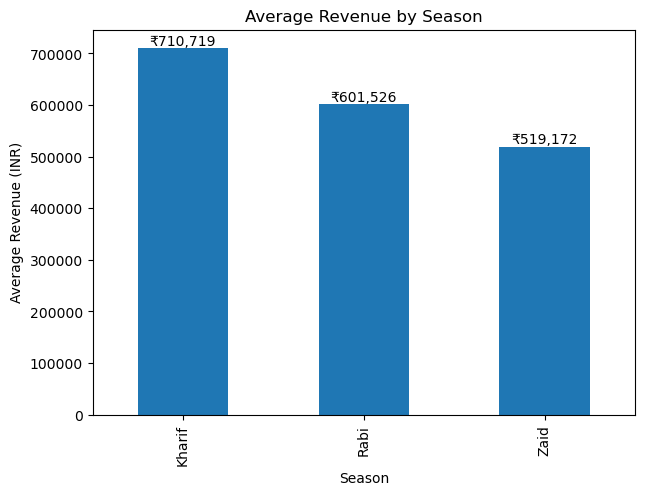

In [69]:
season_revenue = df.groupby('Season')['Revenue_INR'].mean().sort_values(ascending=False)

# Bar chart
plt.figure(figsize=(7, 5))
season_revenue.plot(kind='bar')

plt.title('Average Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Average Revenue (INR)')


for i, value in enumerate(season_revenue.values):
    plt.text(i, value + 0.5, f'₹{value:,.0f}', ha='center', va='bottom')

plt.show()

#### Average Profit by Season

In [70]:
df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64

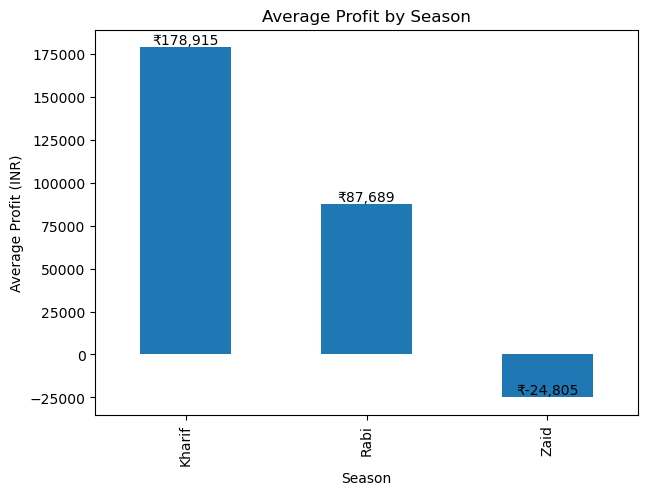

In [71]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

# Bar chart
plt.figure(figsize=(7, 5))
season_profit.plot(kind='bar')

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')


for i, value in enumerate(season_profit.values):
    plt.text(i, value + 0.05, f'₹{value:,.0f}', ha='center', va='bottom')

plt.show()

#### Average Rainfall by Season

In [72]:
df.groupby('Season')['Rainfall_mm'].mean().sort_values(ascending=False)

Season
Kharif    852.112676
Rabi      435.937062
Zaid      299.123232
Name: Rainfall_mm, dtype: float64

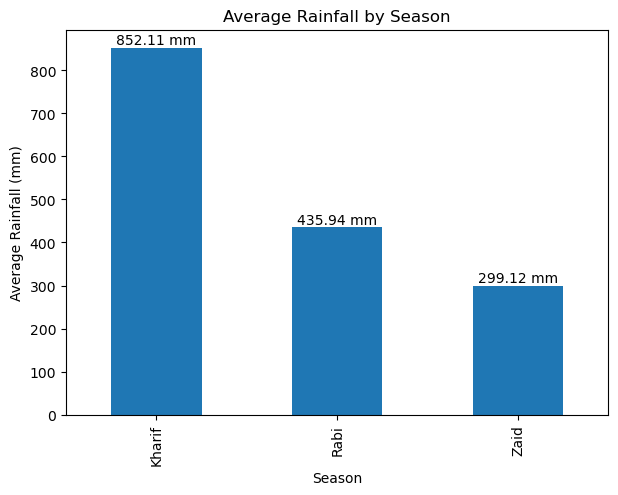

In [73]:
season_rainfall = df.groupby('Season')['Rainfall_mm'].mean().sort_values(ascending=False)

# Bar chart
plt.figure(figsize=(7, 5))
season_rainfall.plot(kind='bar')

plt.title('Average Rainfall by Season')
plt.xlabel('Season')
plt.ylabel('Average Rainfall (mm)')

for i, value in enumerate(season_rainfall.values):
    plt.text(i, value + 0.5, f'{value:.2f} mm', ha='center', va='bottom')
    
plt.show()

#### Average Water Efficiency by Season

In [74]:
df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64

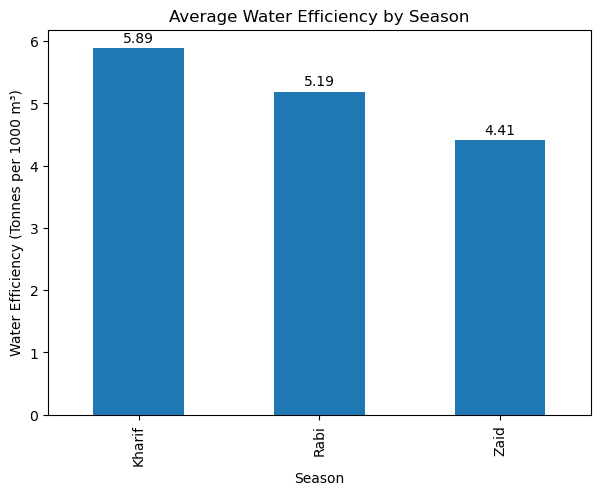

In [75]:
season_water_efficiency = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)

# Bar chart: 
plt.figure(figsize=(7, 5))
season_water_efficiency.plot(kind='bar')

plt.title('Average Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')


for i, value in enumerate(season_water_efficiency.values):
    plt.text(i, value + 0.05, f'{value:.2f}', ha='center', va='bottom')
plt.show()

#### Average Disease and Pest Risk by Season

In [76]:
df.groupby('Season')['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False)

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64

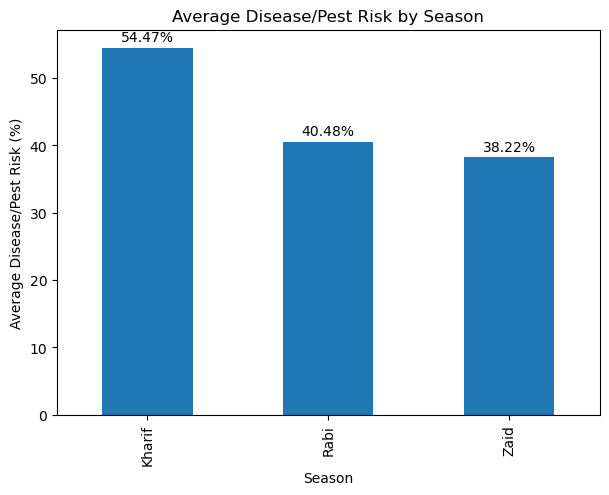

In [77]:
season_risk = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False)

# Bar chart:
plt.figure(figsize=(7, 5))
season_risk.plot(kind='bar')

plt.title('Average Disease/Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Average Disease/Pest Risk (%)')

for i, value in enumerate(season_risk.values):
    plt.text(i, value + 0.5, f'{value:.2f}%', ha='center', va='bottom')

plt.show()

#### Average Soil Moisture by Season

In [78]:
df.groupby('Season')['Soil_Moisture_pct'].mean().sort_values(ascending=False)

Season
Kharif    31.198426
Rabi      24.050215
Zaid      19.169024
Name: Soil_Moisture_pct, dtype: float64

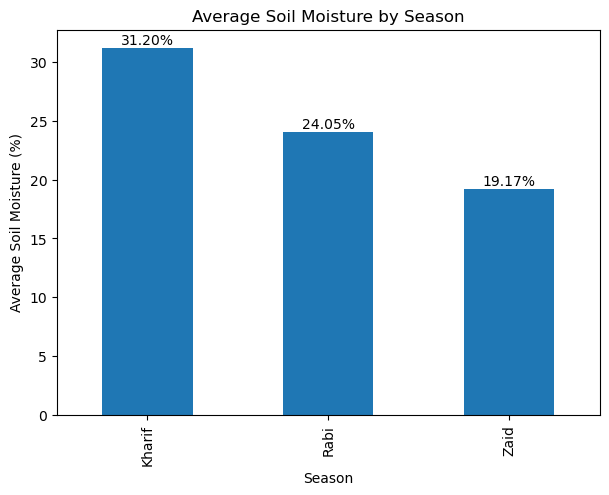

In [79]:
season_soil_moisture = df.groupby('Season')['Soil_Moisture_pct'].mean().sort_values(ascending=False)

# Bar chart:
plt.figure(figsize=(7, 5))
season_soil_moisture.plot(kind='bar')

plt.title('Average Soil Moisture by Season')
plt.xlabel('Season')
plt.ylabel('Average Soil Moisture (%)')

for i, value in enumerate(season_soil_moisture.values):
    plt.text(i, value + 0.05, f'{value:.2f}%', ha='center', va='bottom')

plt.show()

#### Average Temperature by Season

In [80]:
df.groupby('Season')['Avg_Temperature_C'].mean().sort_values(ascending=False)

Season
Zaid      31.042088
Kharif    28.454019
Rabi      23.489183
Name: Avg_Temperature_C, dtype: float64

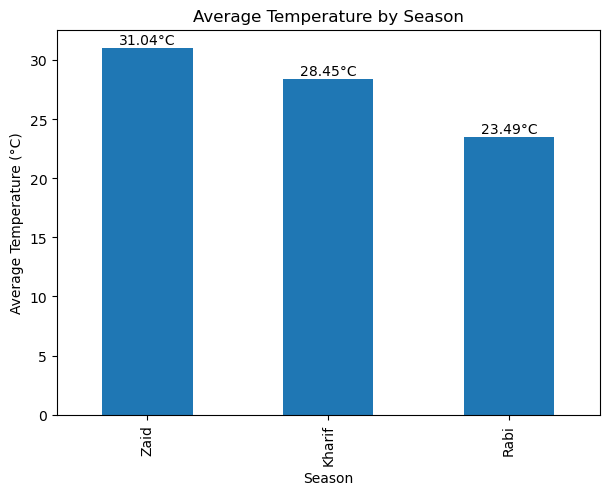

In [81]:
season_temperature = df.groupby('Season')['Avg_Temperature_C'].mean().sort_values(ascending=False)

# Bar chart:
plt.figure(figsize=(7, 5))
season_temperature.plot(kind='bar')

plt.title('Average Temperature by Season')
plt.xlabel('Season')
plt.ylabel('Average Temperature (°C)')

for i, value in enumerate(season_temperature.values):
    plt.text(i, value + 0.05, f'{value:.2f}°C', ha='center', va='bottom')

plt.show()

#### Average Humidity by Season

In [82]:
df.groupby('Season')['Humidity_pct'].mean().sort_values(ascending=False)

Season
Kharif    71.812591
Rabi      57.893178
Zaid      52.012121
Name: Humidity_pct, dtype: float64

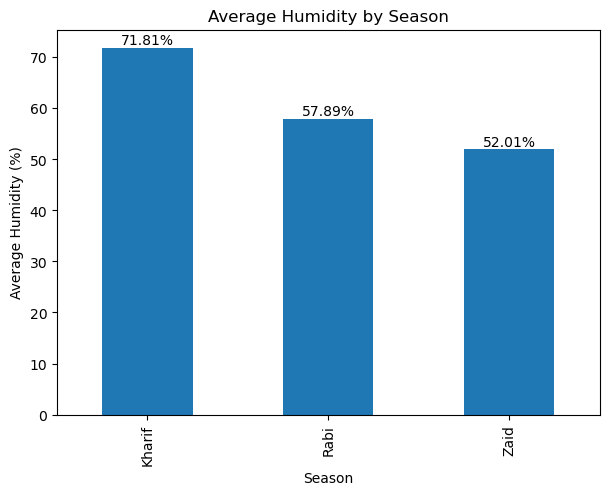

In [83]:
season_humidity = df.groupby('Season')['Humidity_pct'].mean().sort_values(ascending=False)

# Bar chart:
plt.figure(figsize=(7, 5))
season_humidity.plot(kind='bar')

plt.title('Average Humidity by Season')
plt.xlabel('Season')
plt.ylabel('Average Humidity (%)')

for i, value in enumerate(season_humidity.values):
    plt.text(i, value + 0.05, f'{value:.2f}%', ha='center', va='bottom')

plt.show()

#### Average Sunlight Hours by Season

In [84]:
df.groupby('Season')['Sunlight_Hours_Day'].mean().sort_values(ascending=False)

Season
Zaid      8.178788
Rabi      7.589797
Kharif    6.793367
Name: Sunlight_Hours_Day, dtype: float64

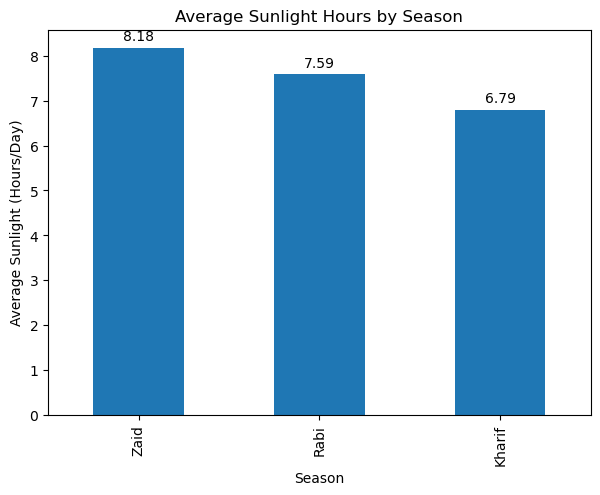

In [85]:
season_sunlight = df.groupby('Season')['Sunlight_Hours_Day'].mean().sort_values(ascending=False)

# Bar chart:
plt.figure(figsize=(7, 5))
season_sunlight.plot(kind='bar')

plt.title('Average Sunlight Hours by Season')
plt.xlabel('Season')
plt.ylabel('Average Sunlight (Hours/Day)')

for i, value in enumerate(season_sunlight.values):
    plt.text(i, value + 0.1, f'{value:.2f}', ha='center', va='bottom')

plt.show()

#### Average Farm Area by Season

In [86]:
df.groupby('Season')['Farm_Area_Hectares'].mean().sort_values(ascending=False)

Season
Zaid      8.091246
Kharif    7.944924
Rabi      7.752207
Name: Farm_Area_Hectares, dtype: float64

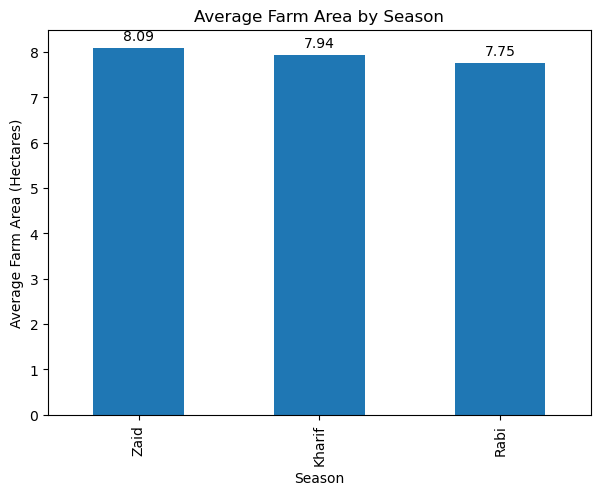

In [87]:
season_farm_area = df.groupby('Season')['Farm_Area_Hectares'].mean().sort_values(ascending=False)

# Bar chart:
plt.figure(figsize=(7, 5))
season_farm_area.plot(kind='bar')

plt.title('Average Farm Area by Season')
plt.xlabel('Season')
plt.ylabel('Average Farm Area (Hectares)')

for i, value in enumerate(season_farm_area.values):
    plt.text(i, value + 0.1, f'{value:.2f}', ha='center', va='bottom')

plt.show()

#### Average Soil pH by Season

In [88]:
df.groupby('Season')['Soil_pH'].mean().sort_values(ascending=False)

Season
Kharif    6.727993
Zaid      6.694865
Rabi      6.673749
Name: Soil_pH, dtype: float64

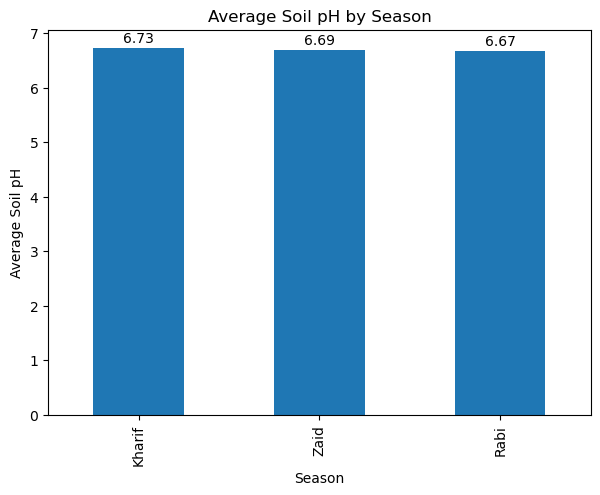

In [89]:
season_soil_ph = df.groupby('Season')['Soil_pH'].mean().sort_values(ascending=False)

# Bar chart:
plt.figure(figsize=(7, 5))
season_soil_ph.plot(kind='bar')

plt.title('Average Soil pH by Season')
plt.xlabel('Season')
plt.ylabel('Average Soil pH')

for i, value in enumerate(season_soil_ph.values):
    plt.text(i, value + 0.05, f'{value:.2f}', ha='center', va='bottom')

plt.show()

####  Average NPK(Nitrogen, Phosphorus, Potassium) Levels by Season

In [90]:
df.groupby('Season')[['Nitrogen_kg_ha', 
                      'Phosphorus_kg_ha', 
                      'Potassium_kg_ha']].mean()

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,
Kharif,120.020124,58.096515,105.303485
Rabi,120.402827,57.311002,103.926060
Zaid,120.525421,58.129125,105.416835


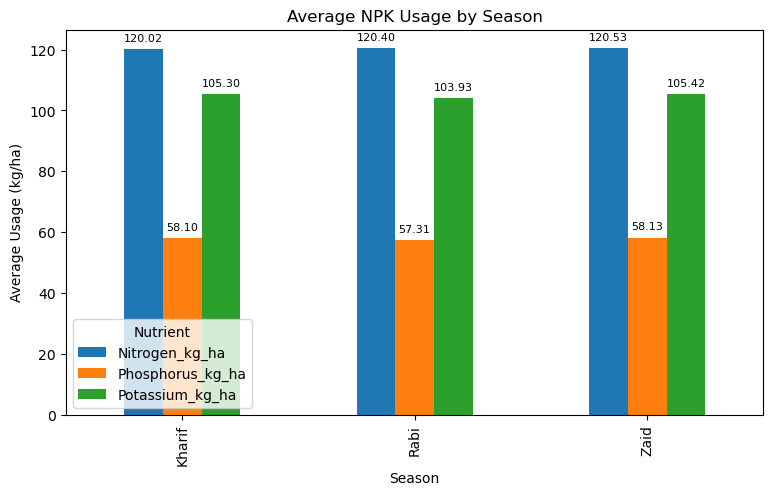

In [91]:
season_npk = df.groupby('Season')[
    ['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha']
].mean()

# Bar chart:
season_npk.plot(kind='bar', figsize=(9, 5))

plt.title('Average NPK Usage by Season')
plt.xlabel('Season')
plt.ylabel('Average Usage (kg/ha)')
plt.legend(title='Nutrient')
for container in plt.gca().containers:
    for bar in container:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, value + 2, f'{value:.2f}', ha='center', va='bottom', fontsize=8
        )
        

plt.show()

#### Average Fertilizer and Pesticide Usage by Season

In [92]:
df.groupby('Season')[['Fertilizer_kg_ha', 
                      'Pesticide_Litre_ha']].mean()

,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,
Kharif,187.077965,5.079747
Rabi,185.407068,5.024690
Zaid,184.638047,5.171212


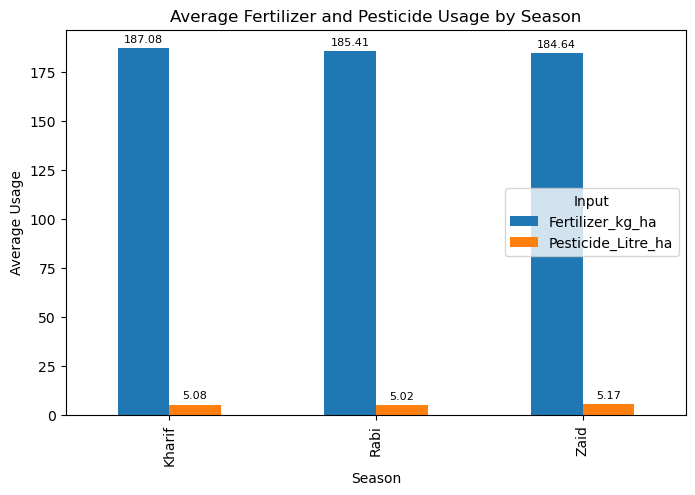

In [93]:
fertilizer_pesticide = df.groupby('Season')[['Fertilizer_kg_ha', 
                                             'Pesticide_Litre_ha']].mean()

fertilizer_pesticide.plot(kind='bar', figsize=(8, 5))

plt.title('Average Fertilizer and Pesticide Usage by Season')
plt.xlabel('Season')
plt.ylabel('Average Usage')
plt.legend(title='Input')

for container in plt.gca().containers:
    for bar in container:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, value + 2, f'{value:.2f}', ha='center', va='bottom', fontsize=8
        )
        
plt.show()

#### Average Seed Quality Score by Season

In [94]:
df.groupby('Season')['Seed_Quality_Score'].mean().sort_values(ascending=False)

Season
Rabi      0.832170
Zaid      0.823165
Kharif    0.821613
Name: Seed_Quality_Score, dtype: float64

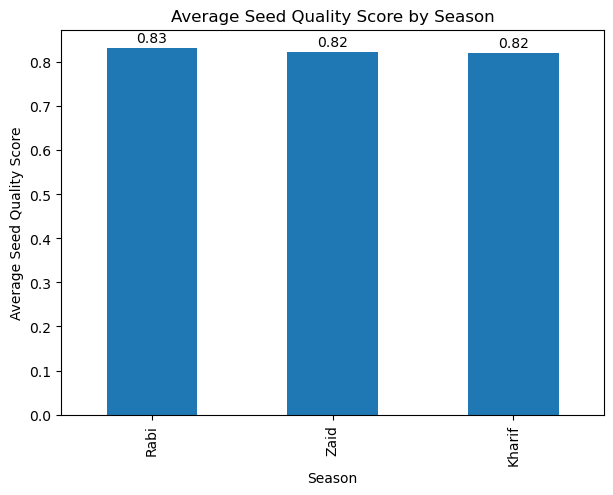

In [95]:
season_seed_quality = df.groupby('Season')['Seed_Quality_Score'].mean().sort_values(ascending=False)

# Bar chart: 
plt.figure(figsize=(7, 5))
season_seed_quality.plot(kind='bar')

plt.title('Average Seed Quality Score by Season')
plt.xlabel('Season')
plt.ylabel('Average Seed Quality Score')

for i, value in enumerate(season_seed_quality.values):
    plt.text(i, value + 0.005, f'{value:.2f}',
             ha='center', va='bottom')

plt.show()

#### Irrigation Methods by Season

In [96]:
df.groupby(['Season', 'Irrigation_Method']).size()

Season  Irrigation_Method
Kharif  Drip                 405
        Flood                590
        Rainfed              463
        Sprinkler            321
Rabi    Drip                 370
        Flood                526
        Rainfed              438
        Sprinkler            293
Zaid    Drip                 140
        Flood                194
        Rainfed              140
        Sprinkler            120
dtype: int64

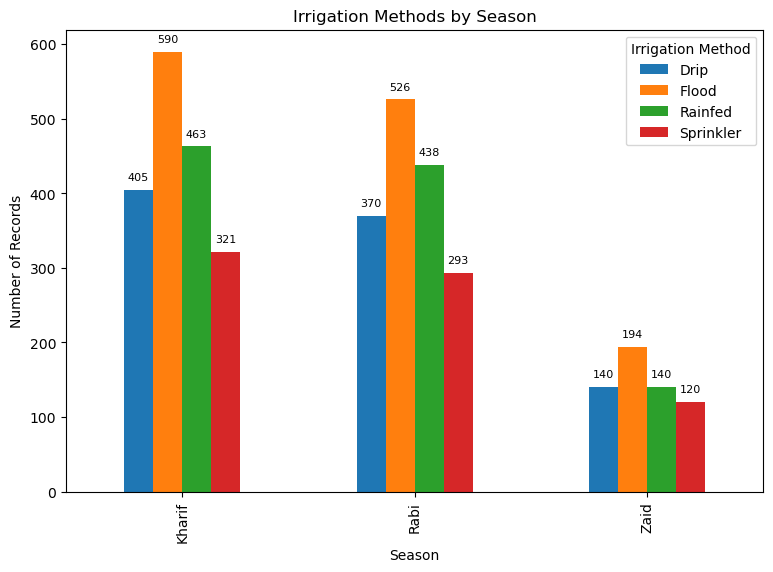

In [97]:
irrigation_season = df.groupby(['Season', 
                                'Irrigation_Method']).size().unstack()

# Bar chart: 
irrigation_season.plot(kind='bar', figsize=(9, 6))

plt.title('Irrigation Methods by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.legend(title='Irrigation Method')

for container in plt.gca().containers:
    for bar in container:
        value = bar.get_height()
        if value > 0:
            plt.text(
                bar.get_x() + bar.get_width() / 2, value + 10, f'{int(value)}', ha='center', va='bottom', fontsize=8
            )

plt.show()

#### Average Revenue vs Total Cost by Season

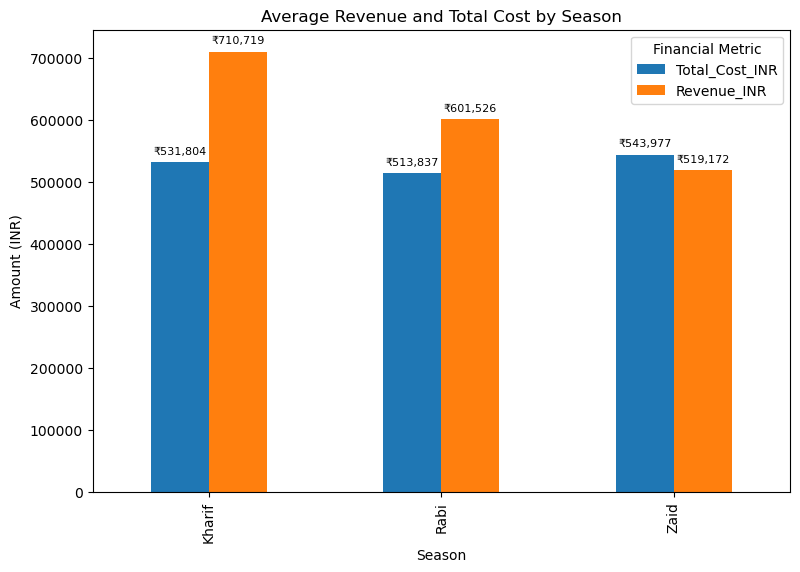

In [98]:
financial = df.groupby('Season')[['Total_Cost_INR', 
                                  'Revenue_INR']].mean()

# Bar chart: 
financial.plot(kind='bar', figsize=(9, 6))

plt.title('Average Revenue and Total Cost by Season')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.legend(title='Financial Metric')


for container in plt.gca().containers:
    for bar in container:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, value + 10000, f'₹{value:,.0f}', ha='center', va='bottom', fontsize=8
            )

plt.show()

#### Average Profit by Season

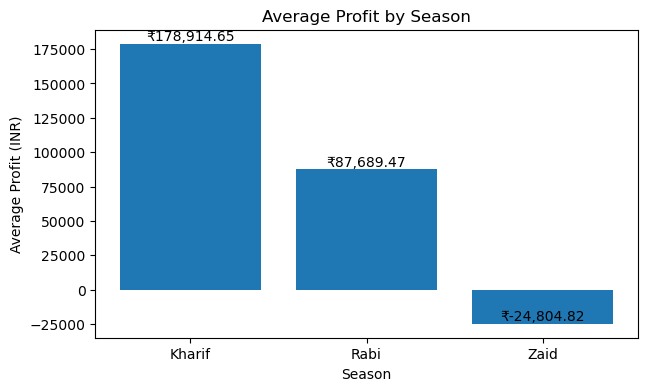

In [99]:
# Average Profit by Season
season_profit = df.groupby('Season')['Profit_INR'].mean()

# Create a bar chart
plt.figure(figsize=(7, 4))
plt.bar(season_profit.index, season_profit.values)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

for i, value in enumerate(season_profit.values):
    plt.text(i, value + 100, f'₹{value:,.2f}', ha='center', va='bottom')

plt.show()

#### Average Water Used by Season

In [100]:
water_used_season = df.groupby('Season')['Water_Used_m3'].mean()
water_used_season

Season
Kharif    6102.201237
Rabi      5846.987093
Zaid      6419.893939
Name: Water_Used_m3, dtype: float64

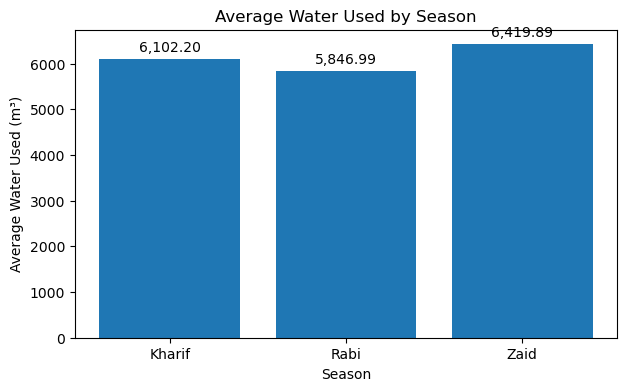

In [101]:
# Average Water Used by Season
season_water = df.groupby('Season')['Water_Used_m3'].mean()

plt.figure(figsize=(7, 4))
plt.bar(season_water.index, season_water.values)

plt.title('Average Water Used by Season')
plt.xlabel('Season')
plt.ylabel('Average Water Used (m³)')

for i, value in enumerate(season_water.values):
    plt.text(i, value + 100, f'{value:,.2f}',
             ha='center', va='bottom')


plt.show()

### Step - 4. Crop Analysis

#### Average Yield by Crop

In [102]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)
crop_yield

Crop
Sugarcane    46.641836
Maize         2.709074
Rice          2.431638
Wheat         2.108225
Chilli        1.541481
Groundnut     1.322642
Cotton        1.229311
Pulses        0.920766
Name: Yield_Tonnes_Ha, dtype: float64

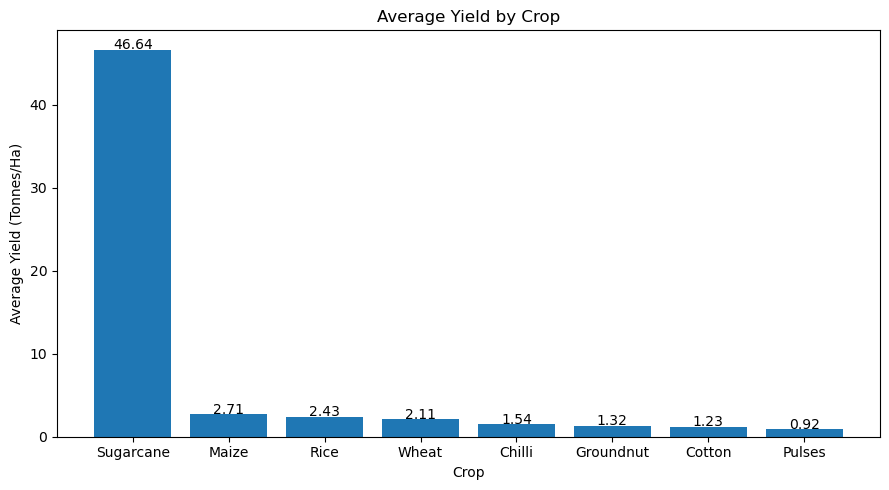

In [103]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

# bar chart
plt.figure(figsize=(9, 5))
plt.bar(crop_yield.index, crop_yield.values)

plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')


for i, value in enumerate(crop_yield.values):
    plt.text(i, value + 0.05, f'{value:.2f}', ha='center')

plt.tight_layout()
plt.show()

#### Average Production by Crop

In [104]:
crop_production = df.groupby('Crop')['Production_Tonnes'].mean().sort_values(ascending=False)
crop_production

Crop
Sugarcane    392.413016
Maize         21.781125
Rice          19.288623
Wheat         16.853909
Chilli        12.382888
Groundnut      9.655825
Cotton         9.395866
Pulses         7.401411
Name: Production_Tonnes, dtype: float64

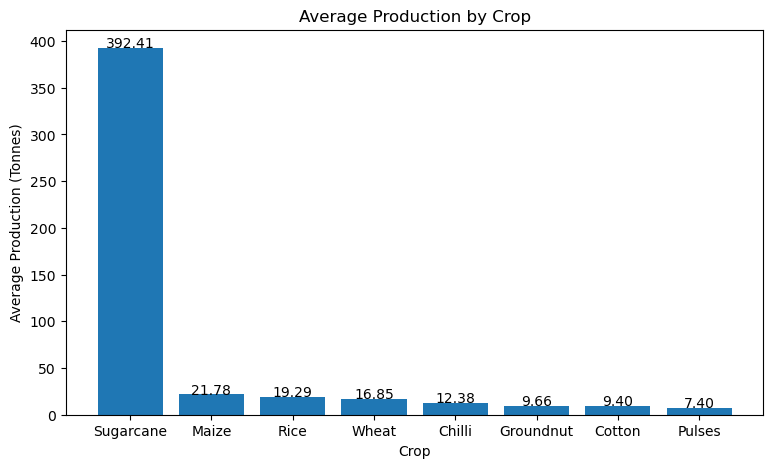

In [105]:
crop_production = df.groupby('Crop')['Production_Tonnes'].mean().sort_values(ascending=False)

# bar chart
plt.figure(figsize=(9, 5))
plt.bar(crop_production.index, crop_production.values)

plt.title('Average Production by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Production (Tonnes)')

for i, value in enumerate(crop_production.values):
    plt.text(i, value + 0.5, f'{value:.2f}', ha='center')

plt.show()

#### Average Revenue vs Total Cost by Crop

In [106]:
financial = df.groupby('Crop')[['Revenue_INR',
                                'Total_Cost_INR']].mean().sort_values('Revenue_INR', ascending=False)
financial

,Revenue_INR,Total_Cost_INR
Crop,,
Sugarcane,1.371980e+06,554792.127869
Chilli,1.276777e+06,525898.885922
Cotton,6.394231e+05,514876.167323
Groundnut,5.429355e+05,498077.377358
Pulses,5.284659e+05,532703.919355
Maize,4.570680e+05,541046.317604
Rice,4.236153e+05,525828.763768
Wheat,4.001049e+05,523503.223127


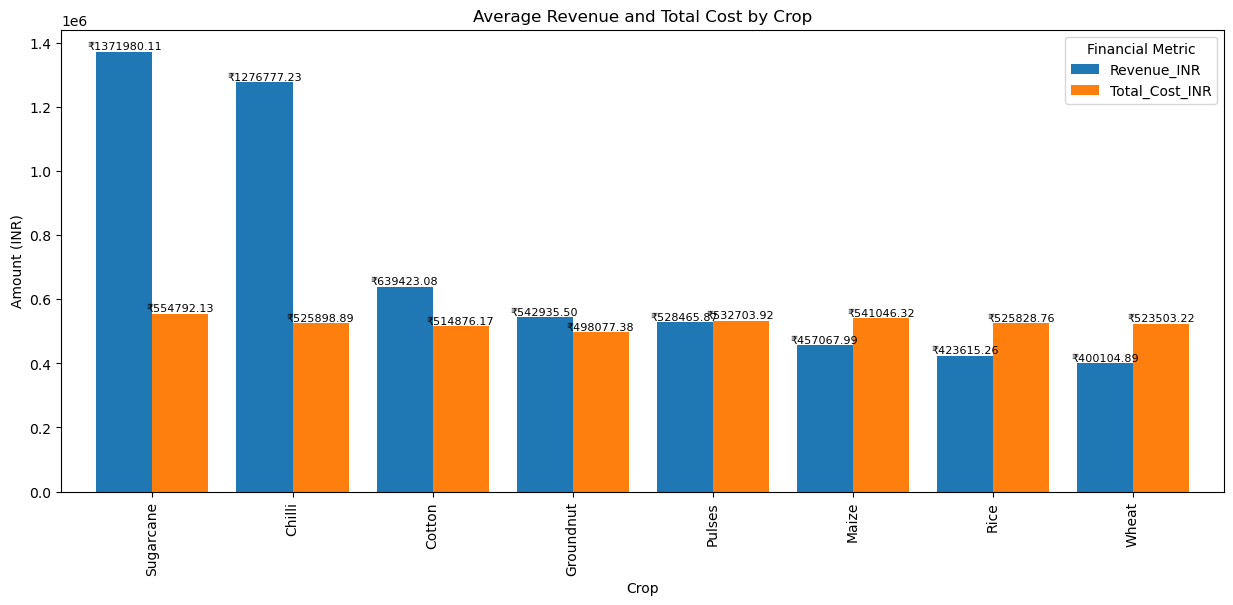

In [107]:
financial.plot(kind='bar', figsize=(15, 6), width=0.8)

plt.title('Average Revenue and Total Cost by Crop')
plt.xlabel('Crop')
plt.ylabel('Amount (INR)')
plt.legend(title='Financial Metric')

for container in plt.gca().containers:
    for bar in container:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,value + 1,f'₹{value:.2f}', ha='center', va='bottom', fontsize=8
        )
plt.show()

#### Average Profit by Crop

In [108]:
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)
crop_profit

Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64

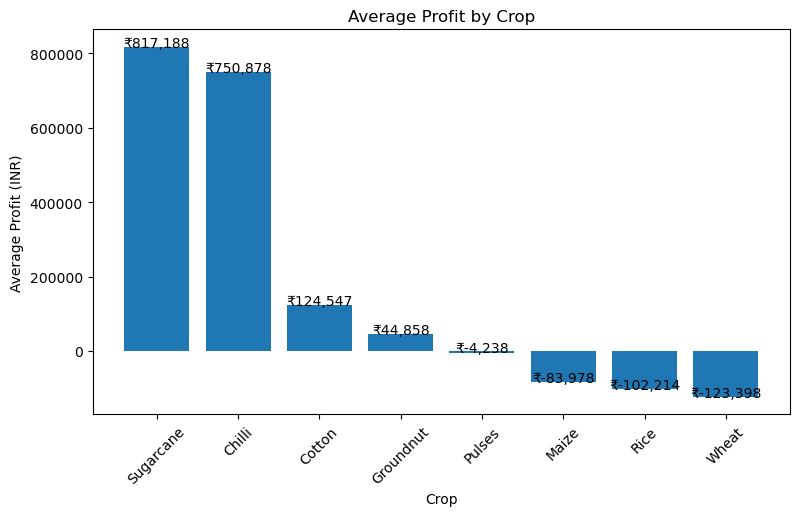

In [109]:
plt.figure(figsize=(9, 5))
plt.bar(crop_profit.index, crop_profit.values)

plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)

for i, value in enumerate(crop_profit.values):
    plt.text(i, value + 0.05, f'₹{value:,.0f}', ha='center')


plt.show()

#### Average Yield by Irrigation Method

In [110]:
irrigation_yield = df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)
irrigation_yield

Irrigation_Method
Drip         6.577290
Sprinkler    5.160082
Flood        4.863366
Rainfed      4.602392
Name: Yield_Tonnes_Ha, dtype: float64

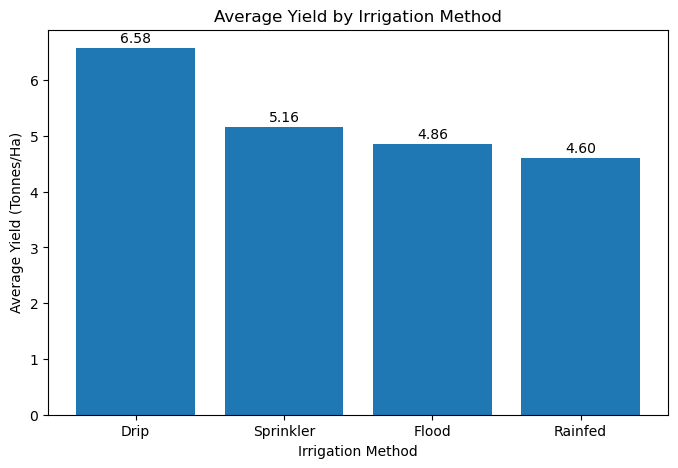

In [111]:
irrigation_yield = df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(irrigation_yield.index, irrigation_yield.values)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')

for i, value in enumerate(irrigation_yield.values):
    plt.text(i, value + 0.1, f'{value:.2f}', ha='center')

plt.show()

#### Average Yield by Crop and Season

In [112]:
crop_season_yield = df.groupby(['Crop','Season'])['Yield_Tonnes_Ha'].mean()

crop_season_yield

Crop       Season
Chilli     Kharif     1.732595
           Rabi       1.464049
           Zaid       1.186250
Cotton     Kharif     1.375488
           Rabi       1.197562
           Zaid       0.957065
Groundnut  Kharif     1.486062
           Rabi       1.231356
           Zaid       1.037778
Maize      Kharif     2.966410
           Rabi       2.602618
           Zaid       2.287500
Pulses     Kharif     1.036063
           Rabi       0.875587
           Zaid       0.665000
Rice       Kharif     2.700382
           Rabi       2.321387
           Zaid       1.900490
Sugarcane  Kharif    53.459120
           Rabi      43.284884
           Zaid      38.423922
Wheat      Kharif     2.254384
           Rabi       2.057131
           Zaid       1.748588
Name: Yield_Tonnes_Ha, dtype: float64

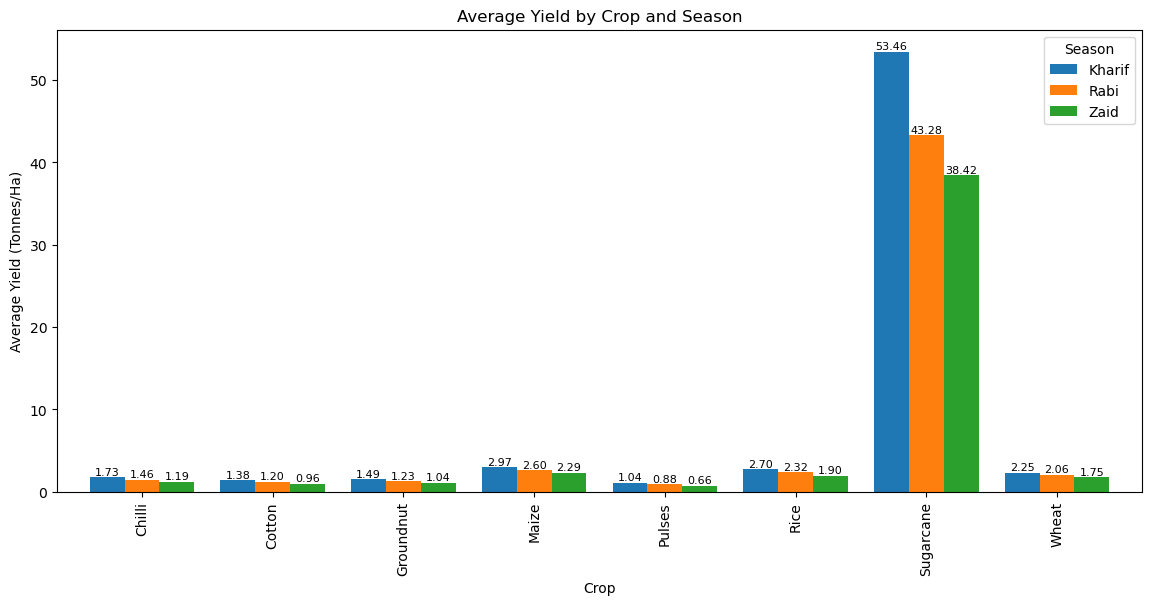

In [113]:
crop_season_yield = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().unstack()

crop_season_yield.plot(
    kind='bar',
    figsize=(14, 6),
    width=0.8
)

plt.title('Average Yield by Crop and Season')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.legend(title='Season')
for container in plt.gca().containers:
    for bar in container:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, value + 0.05, f'{value:.2f}', ha='center', va='bottom', fontsize=8
        )

plt.show()

#### Average Profit by Crop and Season 

In [114]:
crop_season_profit = df.groupby(['Crop', 'Season'])['Profit_INR'].mean()

crop_season_profit

Crop       Season
Chilli     Kharif    9.543804e+05
           Rabi      6.385725e+05
           Zaid      4.486591e+05
Cotton     Kharif    2.169995e+05
           Rabi      1.073436e+05
           Zaid     -5.392534e+04
Groundnut  Kharif    1.082654e+05
           Rabi      1.041654e+04
           Zaid     -6.887250e+04
Maize      Kharif   -3.933267e+04
           Rabi     -8.913340e+04
           Zaid     -1.940492e+05
Pulses     Kharif    4.333890e+04
           Rabi     -1.430914e+04
           Zaid     -1.392278e+05
Rice       Kharif   -6.490340e+04
           Rabi     -9.842787e+04
           Zaid     -2.272393e+05
Sugarcane  Kharif    1.000791e+06
           Rabi      7.316129e+05
           Zaid      5.836358e+05
Wheat      Kharif   -1.058719e+05
           Rabi     -1.199546e+05
           Zaid     -1.932090e+05
Name: Profit_INR, dtype: float64

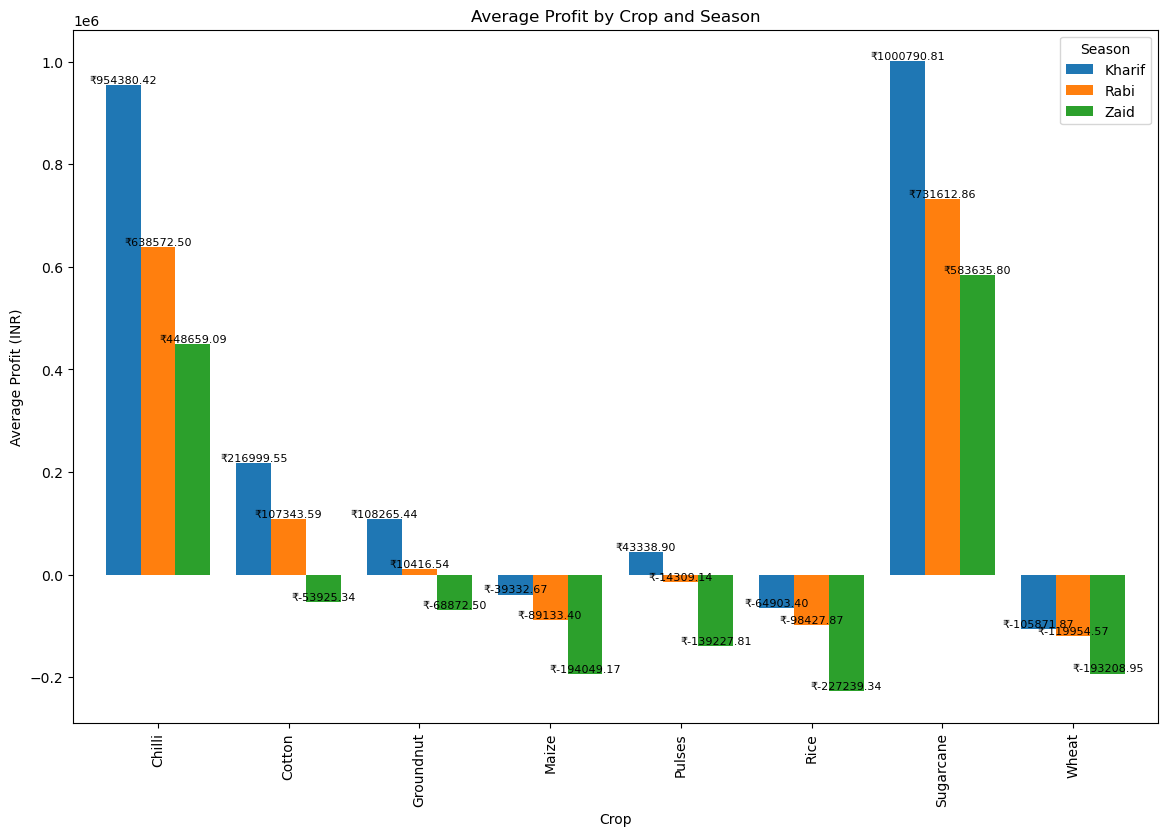

In [115]:
crop_season_profit = df.groupby(
    ['Crop', 'Season']
)['Profit_INR'].mean().unstack()

crop_season_profit.plot(
    kind='bar', figsize=(14, 9), width=0.8
)

plt.title('Average Profit by Crop and Season')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.legend(title='Season')
for container in plt.gca().containers:
    for bar in container:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, value + 0.05, f'₹{value:.2f}', ha='center', va='bottom', fontsize=8
        )

plt.show()

### Step - 5. Irrigation Analysis

In [116]:
irrigation_profit = df.groupby('Irrigation_Method')['Profit_INR'].mean().sort_values(ascending=False)

irrigation_profit

Irrigation_Method
Drip         219625.997814
Sprinkler     91121.079019
Rainfed       79050.365034
Flood         73354.022901
Name: Profit_INR, dtype: float64

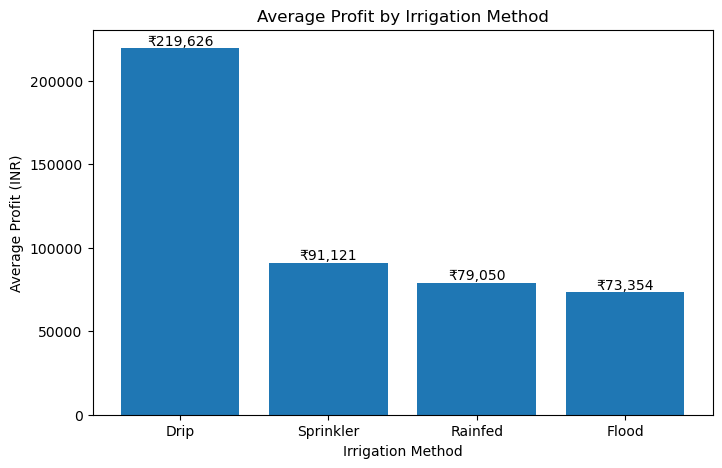

In [117]:
plt.figure(figsize=(8, 5))

plt.bar(
    irrigation_profit.index,
    irrigation_profit.values
)

plt.title('Average Profit by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Profit (INR)')

for i, value in enumerate(irrigation_profit.values):
    plt.text(
        i, value + 0.05, f'₹{value:,.0f}', ha='center', va='bottom'
    )

plt.show()

#### Average Profit by Irrigation Method and Season

In [118]:
irrigation_season_profit = df.groupby(['Irrigation_Method', 'Season'])['Profit_INR'].mean()
irrigation_season_profit

Irrigation_Method  Season
Drip               Kharif    317222.071605
                   Rabi      187843.221622
                   Zaid       21291.835714
Flood              Kharif    133373.832203
                   Rabi       58824.798479
                   Zaid      -69786.778351
Rainfed            Kharif    158974.125270
                   Rabi       45232.479452
                   Zaid      -79467.257143
Sprinkler          Kharif    116880.492212
                   Rabi       76502.068259
                   Zaid       57909.400000
Name: Profit_INR, dtype: float64

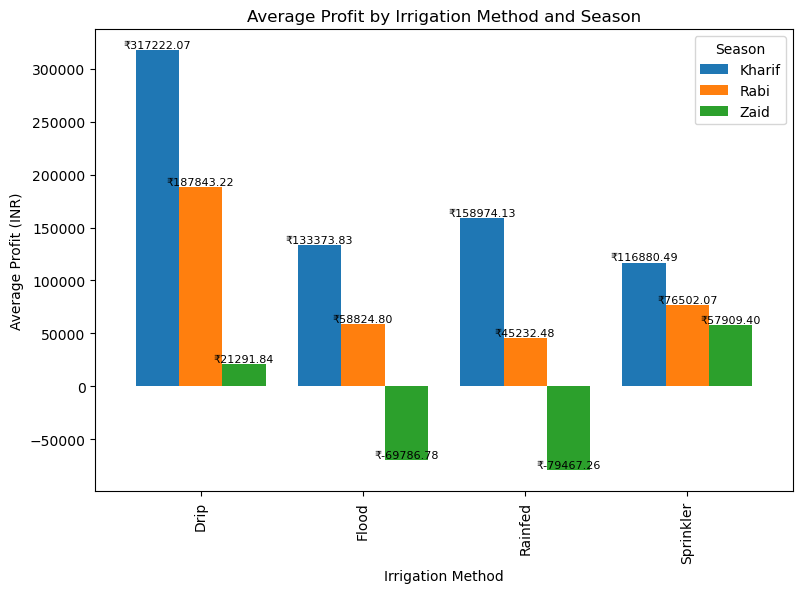

In [119]:
irrigation_season_profit = df.groupby( ['Irrigation_Method', 'Season'])['Profit_INR'].mean().unstack()

irrigation_season_profit.plot(
    kind='bar', figsize=(9, 6), width=0.8
)

plt.title('Average Profit by Irrigation Method and Season')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Profit (INR)')
plt.legend(title='Season')
for container in plt.gca().containers:
    for bar in container:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, value + 0.05, f'₹{value:.2f}', ha='center', va='bottom', fontsize=8
        )

plt.show()

### Step - 6.State & District Analysis

#### Average Yield by State

In [120]:
state_yield = df.groupby('State')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)
state_yield

State
Punjab            6.121116
Karnataka         5.686278
Gujarat           5.657766
Telangana         5.043857
Maharashtra       5.017324
Madhya Pradesh    4.989135
Tamil Nadu        4.874515
Andhra Pradesh    4.628318
Name: Yield_Tonnes_Ha, dtype: float64

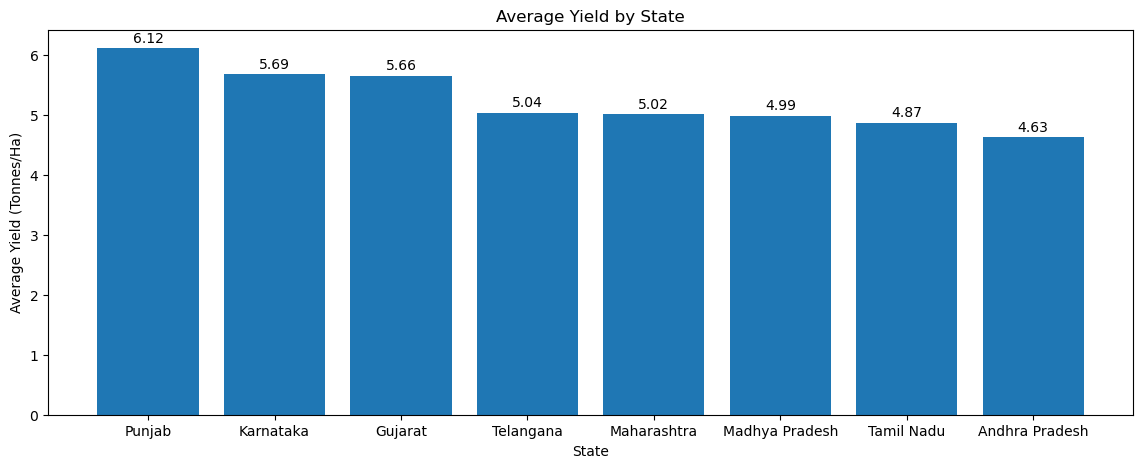

In [121]:
state_yield = df.groupby('State')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))

plt.bar(
    state_yield.index,
    state_yield.values
)

plt.title('Average Yield by State')
plt.xlabel('State')
plt.ylabel('Average Yield (Tonnes/Ha)')

for i, value in enumerate(state_yield.values):
    plt.text(
        i, value + 0.05, f'{value:.2f}', ha='center', va='bottom'
    )

plt.show()

#### Average Profit by State

In [122]:
state_profit = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False)

state_profit

State
Punjab            136025.636364
Maharashtra       135428.855469
Karnataka         119422.335378
Tamil Nadu        117744.748454
Gujarat           117568.235656
Telangana         108829.616279
Madhya Pradesh     86840.756539
Andhra Pradesh     73453.527410
Name: Profit_INR, dtype: float64

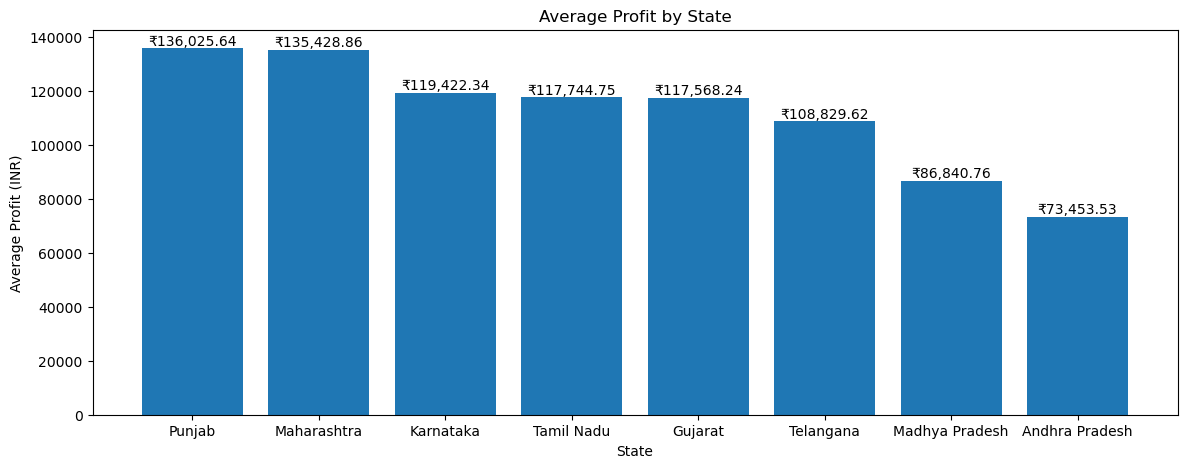

In [123]:
state_profit = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))

plt.bar(
    state_profit.index,
    state_profit.values
)

plt.title('Average Profit by State')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')

for i, value in enumerate(state_profit.values):
    plt.text(
        i, value + 0.05, f'₹{value:,.2f}', ha='center', va='bottom'
    )

plt.show()

#### Average Revenue and Total Cost by State

In [124]:
state_financial = df.groupby('State')[['Revenue_INR', 'Total_Cost_INR']].mean().sort_values('Revenue_INR', ascending=False)

state_financial

,Revenue_INR,Total_Cost_INR
State,,
Punjab,686225.702479,550200.066116
Gujarat,654692.860656,537124.625000
Karnataka,653426.182004,534003.846626
Maharashtra,650032.669922,514603.814453
Tamil Nadu,629093.416495,511348.668041
Telangana,628784.532946,519954.916667
Andhra Pradesh,606663.659735,533210.132325
Madhya Pradesh,597558.358149,510717.601610


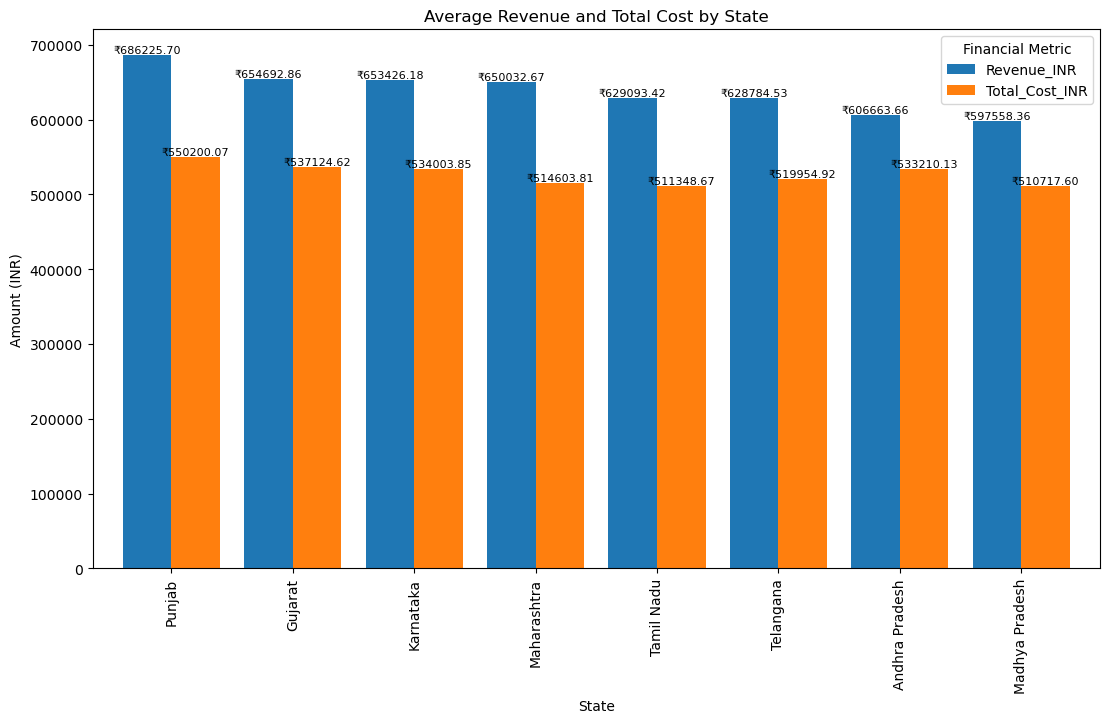

In [125]:
state_financial.plot(
    kind='bar',
    figsize=(13, 7),
    width=0.8
)

plt.title('Average Revenue and Total Cost by State')
plt.xlabel('State')
plt.ylabel('Amount (INR)')
plt.legend(title='Financial Metric')

for container in plt.gca().containers:
    for bar in container:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, value + 0.05, f'₹{value:.2f}', ha='center', va='bottom', fontsize=8
        )
plt.show()

#### Average Yield by District

In [126]:
district_yield = df.groupby('District')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

district_yield

District
Rajkot      6.020673
Nalgonda    5.800096
Ludhiana    5.799625
Warangal    5.501943
Guntur      5.471205
Raichur     4.941995
Indore      4.883240
Nashik      4.864232
Krishna     4.846438
Erode       4.177022
Name: Yield_Tonnes_Ha, dtype: float64

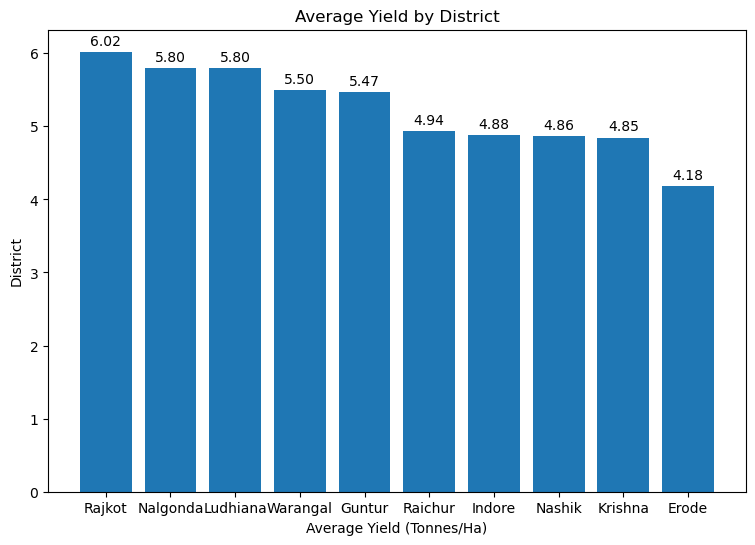

In [127]:
plt.figure(figsize=(9, 6))

plt.bar(district_yield.index, district_yield.values)

plt.title('Average Yield by District')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('District')
for i, value in enumerate(district_yield.values):
    plt.text(
        i, value + 0.05, f'{value:.2f}', ha='center', va='bottom'
    )
    

plt.show()

#### Average Profit by District

In [128]:
district_profit = df.groupby('District')['Profit_INR'].mean().sort_values(ascending=False)

district_profit

District
Warangal    166449.962085
Nalgonda    131125.836145
Raichur     125172.699482
Rajkot      119463.276808
Guntur      116411.417949
Erode       102079.565757
Nashik       94910.172507
Indore       90421.341837
Ludhiana     87590.831382
Krishna      78240.903308
Name: Profit_INR, dtype: float64

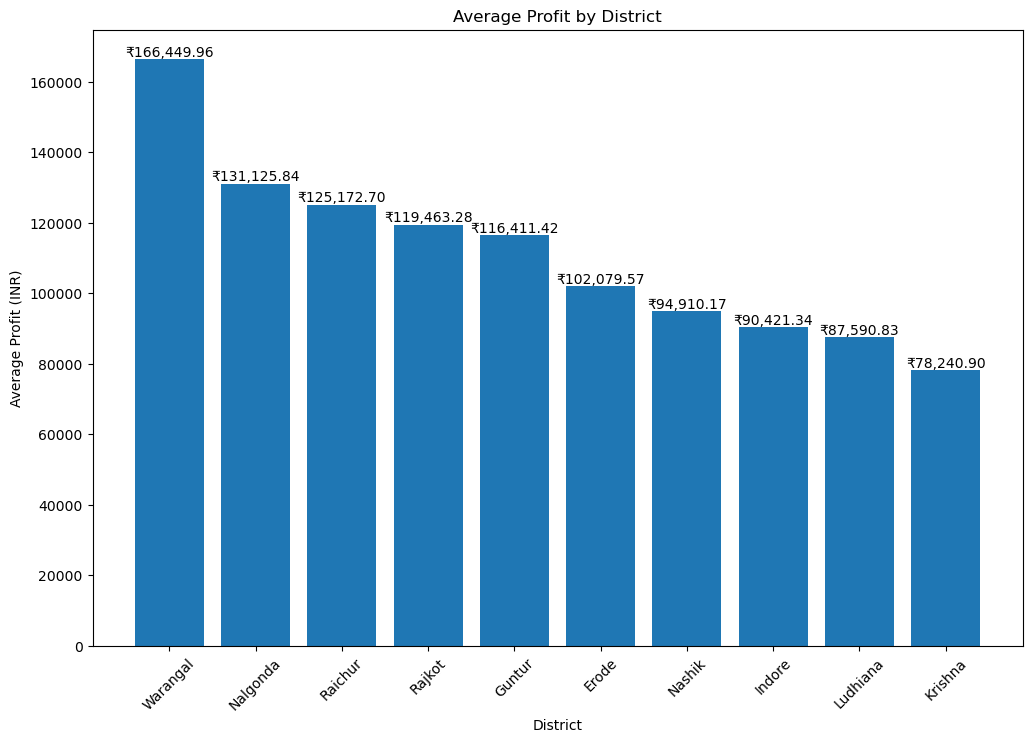

In [129]:
plt.figure(figsize=(12, 8))

plt.bar(district_profit.index, district_profit.values)

plt.title('Average Profit by District')
plt.xlabel('District')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)

for i, value in enumerate(district_profit.values):
    plt.text(
        i, value + 0.05, f'₹{value:,.2f}', ha='center', va='bottom'
    )

plt.show()

#### Average Revenue and Total Cost by Distric

In [130]:
district_financial = df.groupby('District')[['Revenue_INR', 'Total_Cost_INR']].mean().sort_values('Revenue_INR', ascending=False)

district_financial

,Revenue_INR,Total_Cost_INR
District,,
Warangal,703386.386256,536936.424171
Nalgonda,651104.563855,519978.727711
Rajkot,648998.324190,529535.047382
Raichur,637352.417098,512179.717617
Guntur,635094.217949,518682.800000
Erode,630542.699752,528463.133995
Indore,630401.750000,539980.408163
Ludhiana,621442.688525,533851.857143
Nashik,614387.897574,519477.725067


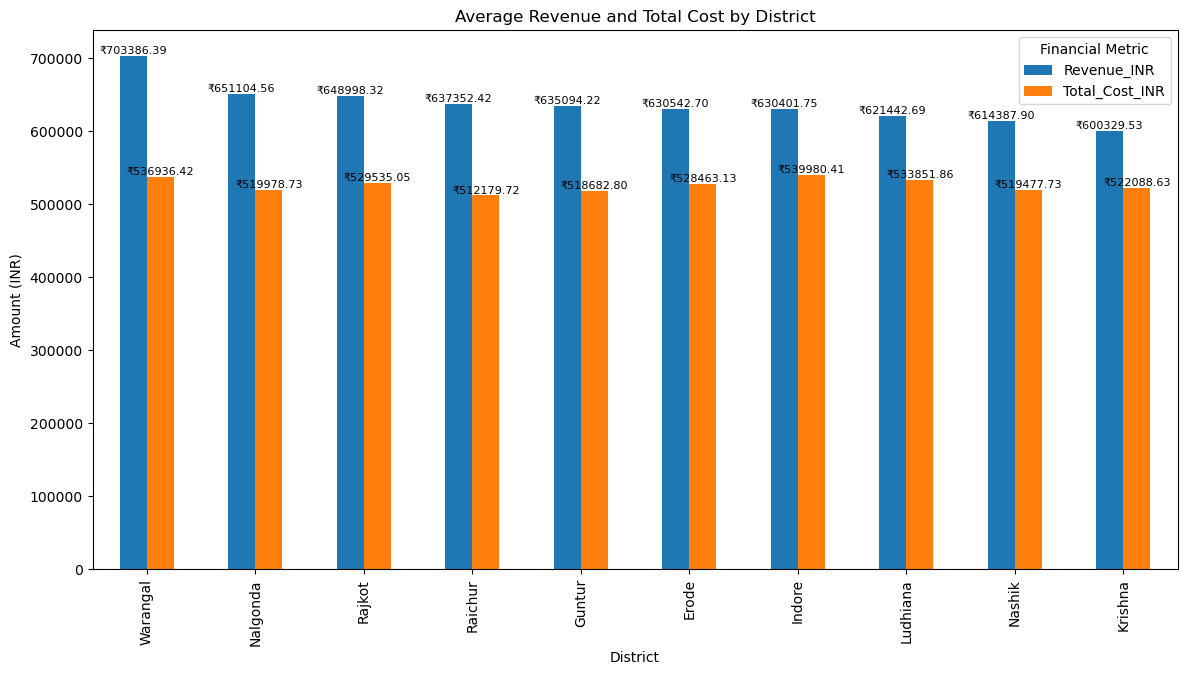

In [131]:
district_financial.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Average Revenue and Total Cost by District')
plt.xlabel('District')
plt.ylabel('Amount (INR)')
plt.legend(title='Financial Metric')
for container in plt.gca().containers:
    for bar in container:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, value + 0.05, f'₹{value:.2f}', ha='center', va='bottom', fontsize=8
        )

plt.show()

### Step - 7. Relationship / Correlation Analysis

#### Yield vs Production

In [132]:
yeild_prodtonn_corr = df['Yield_Tonnes_Ha'].corr(df['Production_Tonnes'])

yeild_prodtonn_corr

np.float64(0.8828040622265012)

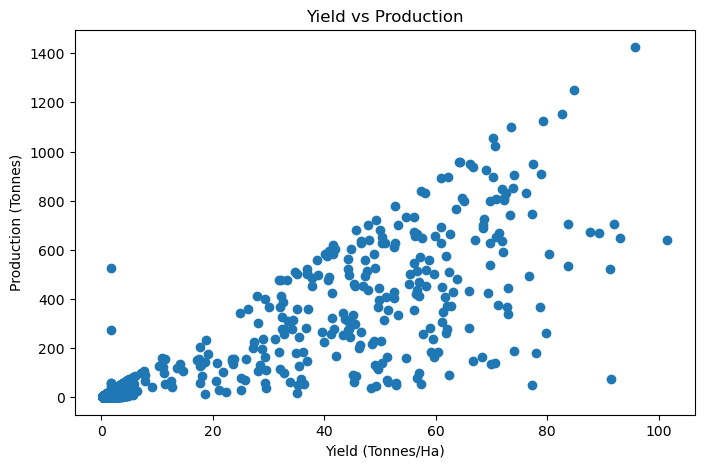

In [133]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Yield_Tonnes_Ha'],
    df['Production_Tonnes']
)

plt.title('Yield vs Production')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Production (Tonnes)')

plt.show()

#### Production vs Water Used

In [134]:
water_prod_corr = df['Production_Tonnes'].corr(df['Water_Used_m3'])
water_prod_corr

np.float64(0.5155568672701037)

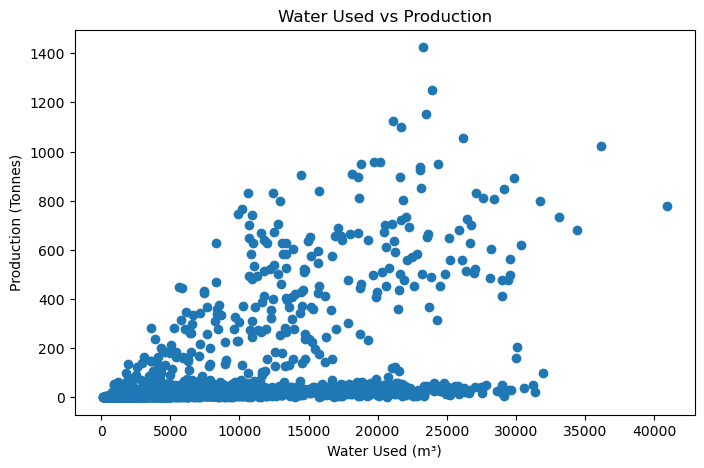

In [135]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Water_Used_m3'],
    df['Production_Tonnes']
)

plt.title('Water Used vs Production')
plt.xlabel('Water Used (m³)')
plt.ylabel('Production (Tonnes)')

plt.show()

#### Yield vs Water Efficiency

In [136]:
yield_watereff_corr = df['Yield_Tonnes_Ha'].corr(df['Water_Efficiency_t_per_1000m3'])

yield_watereff_corr

np.float64(0.9125613689921571)

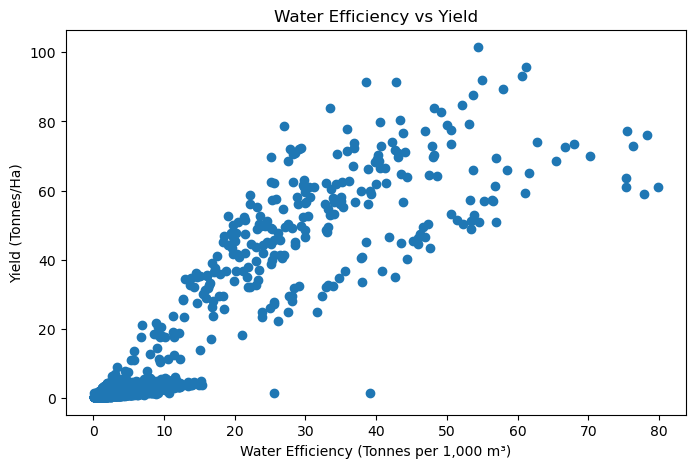

In [137]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Water_Efficiency_t_per_1000m3'],
    df['Yield_Tonnes_Ha']
)

plt.title('Water Efficiency vs Yield')
plt.xlabel('Water Efficiency (Tonnes per 1,000 m³)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

#### Revenue vs Profit

In [138]:
rev_pro_corr = df['Revenue_INR'].corr(df['Profit_INR'])
rev_pro_corr

np.float64(0.8873306756987913)

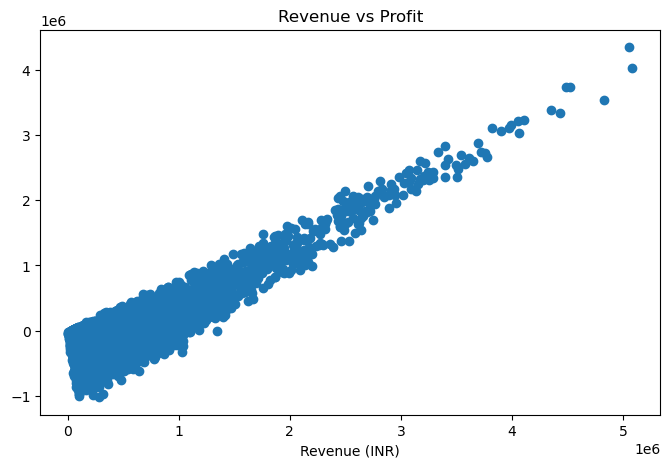

In [139]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Revenue_INR'],
    df['Profit_INR']
)

plt.title('Revenue vs Profit')
plt.xlabel('Revenue (INR)')

plt.show()

#### Farm Area vs Total Cost

In [140]:
fram_cost_corr = df['Farm_Area_Hectares'].corr(df['Total_Cost_INR'])
fram_cost_corr

np.float64(0.962211370392784)

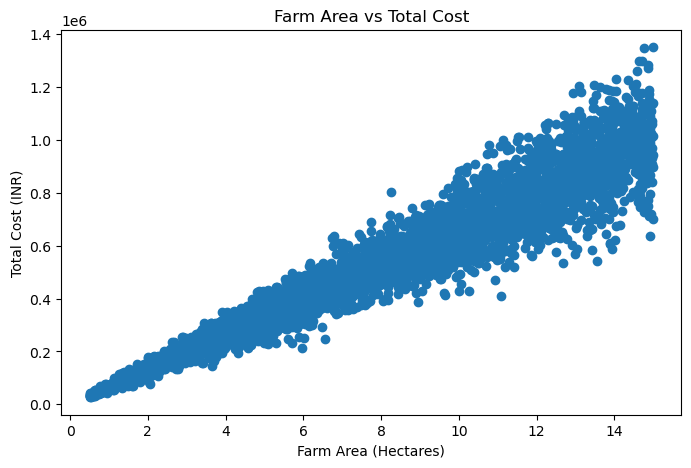

In [141]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Farm_Area_Hectares'],
    df['Total_Cost_INR']
)

plt.title('Farm Area vs Total Cost')
plt.xlabel('Farm Area (Hectares)')
plt.ylabel('Total Cost (INR)')

plt.show()

#### Production vs Water Efficiency

In [142]:
prod_ton_watereff_corr = df['Production_Tonnes'].corr(df['Water_Efficiency_t_per_1000m3'])

prod_ton_watereff_corr

np.float64(0.8121425496724561)

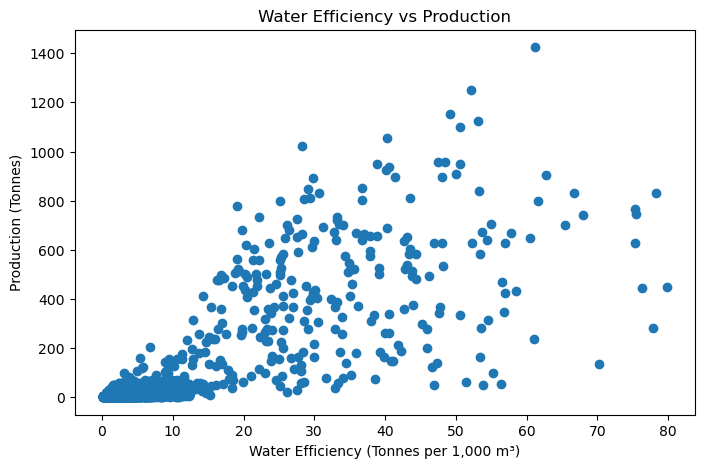

In [143]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Water_Efficiency_t_per_1000m3'],
    df['Production_Tonnes']
)

plt.title('Water Efficiency vs Production')
plt.xlabel('Water Efficiency (Tonnes per 1,000 m³)')
plt.ylabel('Production (Tonnes)')

plt.show()

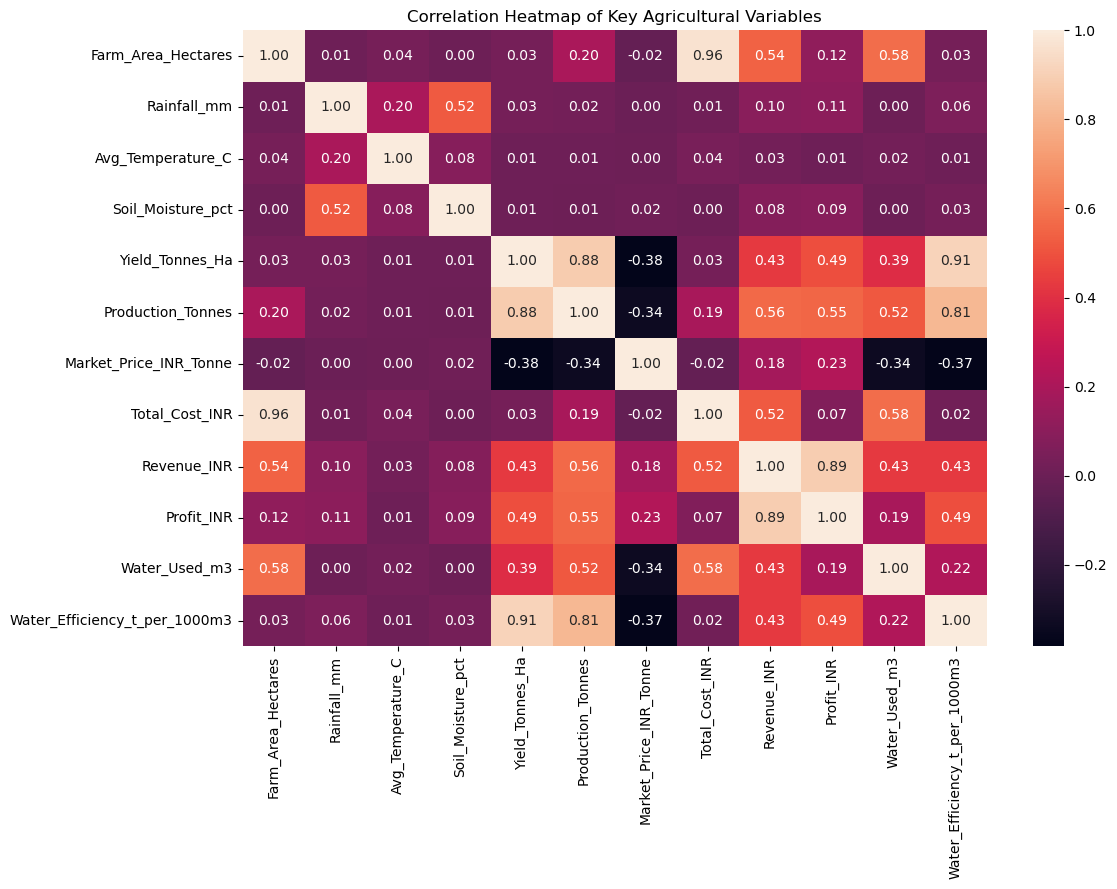

In [144]:
corr_columns = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3'
]

correlation = df[corr_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, fmt='.2f')
plt.title('Correlation Heatmap of Key Agricultural Variables')

plt.show()

### Step - 8. Overall Key Findings

Based on the analysis, the following key findings were identified:

1. **Seasonal Performance**

   * Kharif recorded the highest average yield, production, revenue and profit.
   * Zaid recorded the lowest average yield and production and had a negative average profit.
   * Kharif also had the highest average rainfall, soil moisture and water efficiency.

2. **Crop Performance**

   * Sugarcane recorded the highest average yield and production.
   * Sugarcane and Chilli were the most profitable crops.
   * Wheat, Rice and Maize recorded negative average profits.

3. **Irrigation Performance**

   * Drip irrigation recorded the highest average yield and profit.
   * Drip irrigation was associated with better performance compared with the other irrigation methods.

4. **State and District Performance**

   * Punjab recorded the highest average yield and state-level profit.
   * Warangal recorded the highest average profit among the districts.
   * Rajkot recorded the highest average district-level yield.

5. **Water and Production Relationships**

   * Yield and water efficiency showed a strong positive correlation of approximately **0.913**.
   * Production and water efficiency showed a strong positive correlation of approximately **0.812**.
   * Water usage and production showed a moderate positive correlation of approximately **0.516**.

6. **Financial Relationships**

   * Revenue and profit showed a strong positive correlation of approximately **0.887**.
   * Farm area and total cost showed a very strong positive correlation of approximately **0.962**.


### Overall Conclusion

The analysis shows that agricultural performance varies across seasons, crops, irrigation methods and geographical regions. Kharif, Sugarcane and Drip irrigation showed stronger overall performance in the dataset. Water efficiency was also strongly associated with yield and production, while seasonal differences in profit were statistically significant.


### Interpretation

The analysis shows that agricultural performance varies across seasons, crops, irrigation methods and geographical regions.

* **Kharif performed better overall**, with higher average yield, production, revenue and profit compared with Rabi and Zaid.
* **Sugarcane showed the strongest crop performance**, with the highest average yield, production and profit.
* **Drip irrigation was associated with better yield and profitability** compared with the other irrigation methods.
* **Water efficiency had a strong positive relationship with yield and production**, suggesting that efficient use of water is an important factor in agricultural performance.
* **Punjab showed strong state-level performance**, while Warangal recorded the highest average profit among the districts.
* The financial analysis showed a strong positive relationship between **revenue and profit**, while larger farm areas were strongly associated with higher total costs.

Overall, the analysis indicates that **season, crop selection, irrigation method, water efficiency and geographical location are important areas to consider when evaluating agricultural performance**.


### Final Conclusion

The Seasonal Agriculture Performance Analysis provided useful insights into how agricultural performance varies across seasons, crops, irrigation methods and geographical regions.

The analysis showed that **Kharif performed best overall**, with higher average yield, production, revenue and profit, while Zaid showed relatively lower performance and negative average profit. Among the crops, **Sugarcane and Chilli showed strong financial performance**, while Wheat, Rice and Maize recorded negative average profits.

**Drip irrigation** was associated with higher average yield and profit, and water efficiency showed strong positive relationships with both yield and production. The analysis also highlighted differences in agricultural performance across states and districts, with **Punjab showing strong state-level performance and Warangal recording the highest district-level average profit**.

Correlation analysis helped identify important relationships between agricultural and financial variables

Overall, the project demonstrates how data analysis and visualization can be used to understand agricultural performance, identify important patterns and support **better crop planning, resource management and data-driven agricultural decision-making**.


### Recommendations and Insights

### Key Insights

* **Kharif showed the strongest overall performance**, with higher average yield, production, revenue and profit.
* **Sugarcane and Chilli showed strong financial performance**, while Wheat, Rice and Maize had negative average profits.
* **Drip irrigation was associated with higher average yield and profit** compared with other irrigation methods.
* **Water efficiency showed a strong positive relationship with yield and production**, highlighting the importance of efficient water usage.
* **Punjab showed strong state-level performance**, while Warangal recorded the highest average profit among the districts.

### Recommendations

1. **Improve water efficiency**
   Farmers and agricultural planners can focus on efficient irrigation practices, particularly methods such as drip irrigation.

2. **Focus on profitable crops**
   Crops such as Sugarcane and Chilli showed stronger financial performance in this dataset. Crop selection should also consider local conditions and market demand.

3. **Review low-profit crops**
   Wheat, Rice and Maize showed negative average profits. Their production costs, market prices and resource requirements should be reviewed before making farming decisions.

4. **Use seasonal planning**
   Since Kharif showed stronger overall performance, seasonal planning can consider rainfall, soil moisture, water availability and expected profitability.

5. **Control production costs**
   Monitoring total costs can help improve profitability, especially for crops and regions with lower financial performance.

6. **Use data-driven decision-making**
   Agricultural organizations can use similar analysis to compare crops, irrigation methods, regions and seasons and make better resource allocation decisions.

### Overall Insight

The analysis suggests that **efficient resource usage, suitable crop selection, seasonal planning and cost management** can play an important role in improving agricultural performance.
